# Monster–VIKING Y-band colour transformation

This notebook derives an empirical transformation from Monster DES-system
photometry to the VIRCAM Y band using VIKING DR4 stellar catalogues.
Proper-motion-aware catalogue matching is used to construct a clean calibration
sample, fit and validate the colour spline, and produce the final Monster YAML
transformation.

## 1. Inventory the VIKING Y-band catalogues

This cell checks the available VIKING Y-band catalogues, their observing
epochs, photometric system, source counts, and corresponding Monster shards.

A well-populated catalogue with complete Monster coverage is selected as the
development tile. No matching or colour-term fitting is performed in this
cell.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from astropy.io import fits
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning

from IPython.display import display

import warnings

from astropy.units import UnitsWarning

# Hide warnings caused by non-standard unit strings in VISTA FITS metadata,
# such as "ADU" and "day".
warnings.filterwarnings(
    "ignore",
    category=UnitsWarning,
)

# -------------------------------------------------------------------
# Input and output directories
# -------------------------------------------------------------------

Y_VIKING_DIR = Path(
    "data/VIKING/y_band/viking"
)

Y_MONSTER_ROOT = Path(
    "data/VIKING/y_band/monster"
)

Y_OUTPUT_DIR = Path(
    "data/outputs/Monster_VIKING_Y"
)

Y_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -------------------------------------------------------------------
# Find the input catalogues
# -------------------------------------------------------------------

y_viking_files = sorted(
    Y_VIKING_DIR.glob("*.fits")
)

if not y_viking_files:
    raise FileNotFoundError(
        f"No VIKING Y-band catalogues were found in:\n"
        f"{Y_VIKING_DIR}"
    )

print(
    f"Found {len(y_viking_files)} candidate VIKING Y catalogues."
)


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def find_table_hdu(hdul):
    """Return the first FITS table HDU containing catalogue rows."""

    for hdu in hdul:
        if (
            isinstance(
                hdu,
                (
                    fits.BinTableHDU,
                    fits.TableHDU,
                ),
            )
            and hdu.data is not None
        ):
            return hdu

    raise ValueError(
        "No catalogue table HDU was found."
    )


def get_header_value(
    primary_header,
    table_header,
    keyword,
    default=None,
):
    """Read a keyword from the table or primary FITS header."""

    if keyword in table_header:
        return table_header[keyword]

    if keyword in primary_header:
        return primary_header[keyword]

    return default


def finite_float_array(values):
    """Convert a FITS column to a float array."""

    return np.asarray(
        values,
        dtype=float,
    )


# -------------------------------------------------------------------
# Inspect every Y-band catalogue
# -------------------------------------------------------------------

required_viking_columns = [
    "RA",
    "DEC",
    "MJD",
    "APERFLUX3",
    "APERFLUX3ERR",
    "APERMAG3",
    "APERMAG3ERR",
    "CLASS",
    "CLASSSTAT",
    "PPERRBITS",
]

inventory_records = []


for file_number, y_path in enumerate(
    y_viking_files,
    start=1,
):
    print(
        f"[{file_number:03d}/{len(y_viking_files):03d}] "
        f"{y_path.name}"
    )

    try:
        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore",
                AstropyWarning,
            )

            with fits.open(
                y_path,
                memmap=True,
            ) as hdul:

                catalogue_hdu = find_table_hdu(
                    hdul
                )

                catalogue_data = catalogue_hdu.data

                primary_header = hdul[0].header
                table_header = catalogue_hdu.header

                column_names = set(
                    catalogue_data.names
                )

                missing_columns = [
                    column_name
                    for column_name in required_viking_columns
                    if column_name not in column_names
                ]

                number_of_rows = len(
                    catalogue_data
                )

                filter_name = str(
                    get_header_value(
                        primary_header,
                        table_header,
                        "FILTER",
                        "",
                    )
                ).strip()

                photometric_system = str(
                    get_header_value(
                        primary_header,
                        table_header,
                        "PHOTSYS",
                        "",
                    )
                ).strip()

                header_mjd_obs = get_header_value(
                    primary_header,
                    table_header,
                    "MJD-OBS",
                    np.nan,
                )


                # ---------------------------------------------------
                # Source-level observing epoch
                # ---------------------------------------------------

                if "MJD" in column_names:
                    source_mjd = finite_float_array(
                        catalogue_data["MJD"]
                    )

                    finite_mjd = source_mjd[
                        np.isfinite(source_mjd)
                    ]
                else:
                    finite_mjd = np.array(
                        [],
                        dtype=float,
                    )


                if len(finite_mjd) > 0:
                    source_mjd_median = float(
                        np.median(
                            finite_mjd
                        )
                    )

                    source_mjd_span_days = float(
                        np.max(
                            finite_mjd
                        )
                        - np.min(
                            finite_mjd
                        )
                    )

                    median_epoch_jyear = float(
                        Time(
                            source_mjd_median,
                            format="mjd",
                            scale="utc",
                        ).jyear
                    )

                    unique_epoch_seconds = np.unique(
                        np.rint(
                            finite_mjd
                            * 86400.0
                        ).astype(
                            np.int64
                        )
                    )

                    number_of_unique_epoch_seconds = len(
                        unique_epoch_seconds
                    )

                else:
                    source_mjd_median = np.nan
                    source_mjd_span_days = np.nan
                    median_epoch_jyear = np.nan
                    number_of_unique_epoch_seconds = 0


                # ---------------------------------------------------
                # Approximate Y-band signal-to-noise count
                # ---------------------------------------------------

                if (
                    "APERFLUX3" in column_names
                    and "APERFLUX3ERR" in column_names
                ):
                    aperture_flux = finite_float_array(
                        catalogue_data[
                            "APERFLUX3"
                        ]
                    )

                    aperture_flux_error = finite_float_array(
                        catalogue_data[
                            "APERFLUX3ERR"
                        ]
                    )

                    valid_flux = (
                        np.isfinite(
                            aperture_flux
                        )
                        & np.isfinite(
                            aperture_flux_error
                        )
                        & (
                            aperture_flux
                            > 0.0
                        )
                        & (
                            aperture_flux_error
                            > 0.0
                        )
                    )

                    aperture_snr = np.full(
                        number_of_rows,
                        np.nan,
                        dtype=float,
                    )

                    aperture_snr[
                        valid_flux
                    ] = (
                        aperture_flux[
                            valid_flux
                        ]
                        / aperture_flux_error[
                            valid_flux
                        ]
                    )

                    number_snr_ge_30 = int(
                        np.count_nonzero(
                            aperture_snr >= 30.0
                        )
                    )

                else:
                    number_snr_ge_30 = 0


                # ---------------------------------------------------
                # Approximate survey region
                # ---------------------------------------------------

                if "DEC" in column_names:
                    declination = finite_float_array(
                        catalogue_data["DEC"]
                    )

                    finite_declination = declination[
                        np.isfinite(
                            declination
                        )
                    ]

                    median_declination = (
                        float(
                            np.median(
                                finite_declination
                            )
                        )
                        if len(
                            finite_declination
                        ) > 0
                        else np.nan
                    )
                else:
                    median_declination = np.nan


                region = (
                    "southern"
                    if (
                        np.isfinite(
                            median_declination
                        )
                        and median_declination < -20.0
                    )
                    else "northern_equatorial"
                )


        # -----------------------------------------------------------
        # Corresponding Monster shards
        # -----------------------------------------------------------

        monster_directory = (
            Y_MONSTER_ROOT
            / y_path.stem
        )

        monster_paths = sorted(
            monster_directory.glob(
                "*.fits"
            )
        )


        inventory_records.append(
            {
                "viking_file":
                    y_path.name,

                "region":
                    region,

                "n_rows":
                    number_of_rows,

                "filter":
                    filter_name,

                "photsys":
                    photometric_system,

                "header_mjd_obs":
                    float(
                        header_mjd_obs
                    )
                    if header_mjd_obs is not None
                    else np.nan,

                "source_mjd_median":
                    source_mjd_median,

                "source_mjd_span_days":
                    source_mjd_span_days,

                "n_unique_epoch_seconds":
                    number_of_unique_epoch_seconds,

                "median_epoch_jyear":
                    median_epoch_jyear,

                "n_snr_ge_30":
                    number_snr_ge_30,

                "n_monster_shards":
                    len(
                        monster_paths
                    ),

                "missing_columns":
                    ", ".join(
                        missing_columns
                    ),

                "status":
                    "OK",
            }
        )


    except Exception as error:
        inventory_records.append(
            {
                "viking_file":
                    y_path.name,

                "status":
                    "FAILED",

                "error":
                    repr(
                        error
                    ),
            }
        )

        print(
            f"    FAILED: {error}"
        )


# -------------------------------------------------------------------
# Build and inspect the inventory table
# -------------------------------------------------------------------

y_inventory = pd.DataFrame(
    inventory_records
)

successful_y_inventory = y_inventory[
    y_inventory["status"] == "OK"
].copy()

failed_y_inventory = y_inventory[
    y_inventory["status"] != "OK"
].copy()


print("\n" + "=" * 72)
print("Y-BAND INPUT SUMMARY")
print("=" * 72)

print(
    f"Input catalogues             : "
    f"{len(y_viking_files)}"
)

print(
    f"Successfully inspected       : "
    f"{len(successful_y_inventory)}"
)

print(
    f"Failed catalogues            : "
    f"{len(failed_y_inventory)}"
)

print(
    f"Catalogues with Monster data : "
    f"{np.count_nonzero(successful_y_inventory['n_monster_shards'] > 0)}"
)


print("\nFilter values")
print("-------------")

display(
    successful_y_inventory[
        "filter"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "filter"
    ).reset_index(
        name="number_of_catalogues"
    )
)


print("\nPhotometric systems")
print("-------------------")

display(
    successful_y_inventory[
        "photsys"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "photsys"
    ).reset_index(
        name="number_of_catalogues"
    )
)


# -------------------------------------------------------------------
# Select a development tile
# -------------------------------------------------------------------

development_candidates = successful_y_inventory[
    (
        successful_y_inventory[
            "n_monster_shards"
        ]
        > 0
    )
    & (
        successful_y_inventory[
            "missing_columns"
        ]
        == ""
    )
].copy()


if len(development_candidates) == 0:
    raise RuntimeError(
        "No Y-band catalogue has both complete required columns "
        "and corresponding Monster shards."
    )


development_candidates = (
    development_candidates
    .sort_values(
        [
            "n_snr_ge_30",
            "n_monster_shards",
            "n_rows",
        ],
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("\nTop development-tile candidates")
print("-------------------------------")

display(
    development_candidates[
        [
            "viking_file",
            "region",
            "n_rows",
            "filter",
            "photsys",
            "median_epoch_jyear",
            "n_snr_ge_30",
            "n_monster_shards",
        ]
    ].head(
        10
    )
)


selected_y_development_row = (
    development_candidates.iloc[0]
)

y_development_tile_path = (
    Y_VIKING_DIR
    / selected_y_development_row[
        "viking_file"
    ]
)

y_development_monster_paths = sorted(
    (
        Y_MONSTER_ROOT
        / y_development_tile_path.stem
    ).glob(
        "*.fits"
    )
)


print("\n" + "=" * 72)
print("SELECTED Y-BAND DEVELOPMENT TILE")
print("=" * 72)

for column_name in [
    "viking_file",
    "region",
    "n_rows",
    "filter",
    "photsys",
    "header_mjd_obs",
    "source_mjd_median",
    "source_mjd_span_days",
    "n_unique_epoch_seconds",
    "median_epoch_jyear",
    "n_snr_ge_30",
    "n_monster_shards",
]:
    print(
        f"{column_name:28s}: "
        f"{selected_y_development_row[column_name]}"
    )


# -------------------------------------------------------------------
# Check Y-specific Monster photometric columns
# -------------------------------------------------------------------

with fits.open(
    y_development_monster_paths[0],
    memmap=True,
) as hdul:

    monster_hdu = find_table_hdu(
        hdul
    )

    monster_column_names = list(
        monster_hdu.columns.names
    )


expected_y_monster_columns = [
    "id",
    "coord_ra",
    "coord_dec",
    "epoch",
    "pm_ra",
    "pm_dec",
    "monster_DES_z_flux",
    "monster_DES_z_fluxErr",
    "monster_DES_y_flux",
    "monster_DES_y_fluxErr",
]

missing_y_monster_columns = [
    column_name
    for column_name in expected_y_monster_columns
    if column_name not in monster_column_names
]


print("\nMonster Y-calibration column check")
print("----------------------------------")

print(
    f"Example Monster shard: "
    f"{y_development_monster_paths[0].name}"
)

print(
    f"Missing expected columns: "
    f"{missing_y_monster_columns}"
)


relevant_monster_columns = [
    column_name
    for column_name in monster_column_names
    if (
        "DES_" in column_name
        and "flux" in column_name
    )
]


print("\nAvailable Monster DES flux columns:")
for column_name in relevant_monster_columns:
    print(
        f"  {column_name}"
    )


# -------------------------------------------------------------------
# Save the inventory
# -------------------------------------------------------------------

y_inventory_path = (
    Y_OUTPUT_DIR
    / "viking_y_catalogue_inventory.csv"
)

y_inventory.to_csv(
    y_inventory_path,
    index=False,
)

print(
    f"\nSaved inventory:\n"
    f"{y_inventory_path}"
)


print("\nPrepared variables for the next cell:")
print(
    "  y_inventory                    : "
    "Y-band catalogue inventory"
)

print(
    "  y_development_tile_path        : "
    "selected development catalogue"
)

print(
    "  y_development_monster_paths    : "
    "Monster shards for that catalogue"
)

Found 87 candidate VIKING Y catalogues.
[001/087] ADP.2020-03-02T18:38:28.598.fits
[002/087] ADP.2020-03-02T18:38:28.603.fits
[003/087] ADP.2020-03-02T18:38:28.718.fits
[004/087] ADP.2020-03-02T18:38:28.792.fits
[005/087] ADP.2020-03-02T18:38:28.830.fits
[006/087] ADP.2020-03-02T18:38:28.991.fits
[007/087] ADP.2020-03-02T18:38:29.048.fits
[008/087] ADP.2020-03-02T18:38:29.184.fits
[009/087] ADP.2020-03-02T18:38:29.312.fits
[010/087] ADP.2020-03-02T18:38:29.446.fits
[011/087] ADP.2020-03-02T18:38:29.524.fits
[012/087] ADP.2020-03-02T18:38:29.926.fits
[013/087] ADP.2020-03-02T18:38:30.000.fits
[014/087] ADP.2020-03-02T18:38:30.120.fits
[015/087] ADP.2020-03-02T18:38:30.214.fits
[016/087] ADP.2020-03-02T18:38:30.258.fits
[017/087] ADP.2020-03-02T18:38:30.298.fits
[018/087] ADP.2020-03-02T18:38:30.512.fits
[019/087] ADP.2020-03-02T18:38:30.734.fits
[020/087] ADP.2020-03-02T18:38:30.743.fits
[021/087] ADP.2020-03-02T18:38:30.915.fits
[022/087] ADP.2020-03-02T18:38:31.068.fits
[023/087] ADP.

,filter,number_of_catalogues
0,Y,87



Photometric systems
-------------------


,photsys,number_of_catalogues
0,VEGA,87



Top development-tile candidates
-------------------------------


,viking_file,region,n_rows,filter,photsys,median_epoch_jyear,n_snr_ge_30,n_monster_shards
0,ADP.2020-03-02T18:38:39.945.fits,northern_equatorial,85634,Y,VEGA,2016.245610,23437,32
1,ADP.2020-03-02T18:38:40.691.fits,northern_equatorial,85049,Y,VEGA,2016.283963,20530,27
2,ADP.2020-03-02T18:38:40.650.fits,northern_equatorial,77747,Y,VEGA,2016.330497,19581,27
3,ADP.2020-03-02T18:38:39.702.fits,northern_equatorial,83786,Y,VEGA,2016.286993,18723,27
4,ADP.2020-03-02T18:38:40.842.fits,northern_equatorial,69876,Y,VEGA,2016.322585,18416,27
5,ADP.2020-03-02T18:38:40.891.fits,northern_equatorial,71679,Y,VEGA,2016.284407,18356,27
6,ADP.2020-03-02T18:38:40.082.fits,northern_equatorial,81019,Y,VEGA,2016.289671,18085,27
7,ADP.2020-03-02T18:38:40.116.fits,northern_equatorial,77220,Y,VEGA,2016.245746,18025,28
8,ADP.2020-03-02T18:38:40.305.fits,northern_equatorial,72034,Y,VEGA,2016.270475,17857,26
9,ADP.2020-03-02T18:38:39.872.fits,northern_equatorial,77423,Y,VEGA,2016.287136,17639,27



SELECTED Y-BAND DEVELOPMENT TILE
viking_file                 : ADP.2020-03-02T18:38:39.945.fits
region                      : northern_equatorial
n_rows                      : 85634
filter                      : Y
photsys                     : VEGA
header_mjd_obs              : 57478.20116997
source_mjd_median           : 57478.20912761688
source_mjd_span_days        : 0.01474052005505655
n_unique_epoch_seconds      : 1179
median_epoch_jyear          : 2016.2456102056587
n_snr_ge_30                 : 23437
n_monster_shards            : 32

Monster Y-calibration column check
----------------------------------
Example Monster shard: monster_htm7_215057.fits
Missing expected columns: []

Available Monster DES flux columns:
  monster_DES_g_flux
  monster_DES_g_fluxErr
  monster_DES_i_flux
  monster_DES_i_fluxErr
  monster_DES_r_flux
  monster_DES_r_fluxErr
  monster_DES_y_flux
  monster_DES_y_fluxErr
  monster_DES_z_flux
  monster_DES_z_fluxErr

Saved inventory:
data/outputs/Monster_VIKIN

### Result

All 87 VIKING Y-band catalogues were inspected successfully. Every catalogue
is in the native VISTA Vega-like system and has corresponding Monster shards.

The development tile is
`ADP.2020-03-02T18:38:39.945.fits`, containing 85,634 VIKING sources and
32 Monster shards. Its median observing epoch is 2016.2456, and all required
Monster DES z- and y-band flux columns are available.

## 2. Match the development tile and construct the Y-band test sample

Monster positions are propagated to the recorded observing epoch of the
selected VIKING Y-band tile. Gold associations require:

- valid Monster coordinates, epoch, and two-component proper motion;
- Monster second-neighbour distance greater than 1 arcsec;
- mutual nearest-neighbour matching;
- separation smaller than 0.5 arcsec.

For the initial photometric sample, an additional separation limit of
0.3 arcsec is used together with stellar classification, clean VIKING flags,
absolute CLASSSTAT below 3, and signal-to-noise ratio of at least 50 in
VIKING Y and Monster DES z and y.

The native VIKING Y magnitudes are converted using:

    Y_AB = Y_native + 0.622

The colour and flux ratio used for the transformation are:

    colour = Monster (z - y)
    ratio  = Monster_y / VISTA_Y

No magnitude or colour-range restriction is imposed yet. These limits will be
selected after inspecting the development-tile results.

,stage,number_remaining,fraction_of_gold
0,Gold matches,18743,1.000000
1,Finite colour and ratio,2935,0.156592
2,Separation < 0.3 arcsec,2914,0.155471
3,CLASS = -1,2823,0.150616
4,Absolute CLASSSTAT < 3,2685,0.143253
5,S/N >= 50 in all bands,1317,0.070266
6,PPERRBITS = 0,743,0.039641



Y-BAND DEVELOPMENT-TILE SAMPLE
VIKING catalogue rows       : 85,634
Unique Monster rows         : 98,236
Valid Monster PM sources    : 77,367
Isolated Monster sources    : 76,983
Mutual nearest neighbours   : 19,108
Gold matches within 0.5     : 18,743
Quality calibration stars   : 743
Median Gold separation      : 0.1274 arcsec
Median residual RA          : +0.0239 arcsec
Median residual Dec         : +0.0983 arcsec
Colour 1st--99th percentile : -0.0674 to 0.1608
Native Y magnitude range    : 12.273 to 16.331
Median Y flux ratio         : 0.901407
Y flux-ratio NMAD           : 0.025649


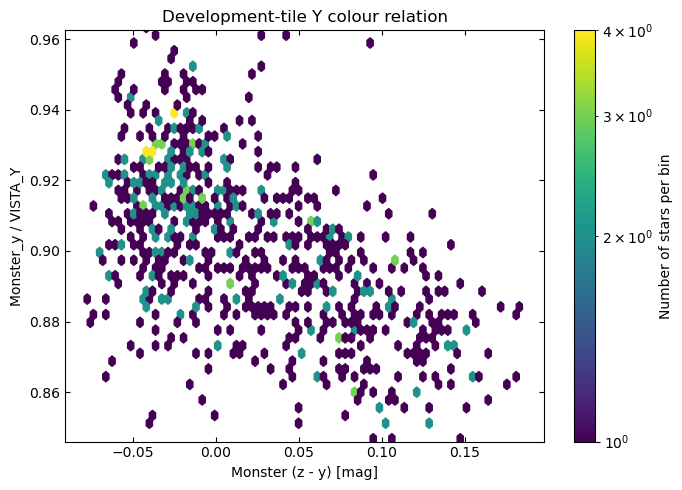

Saved: data/outputs/Monster_VIKING_Y/development_tile_y_colour_relation.pdf


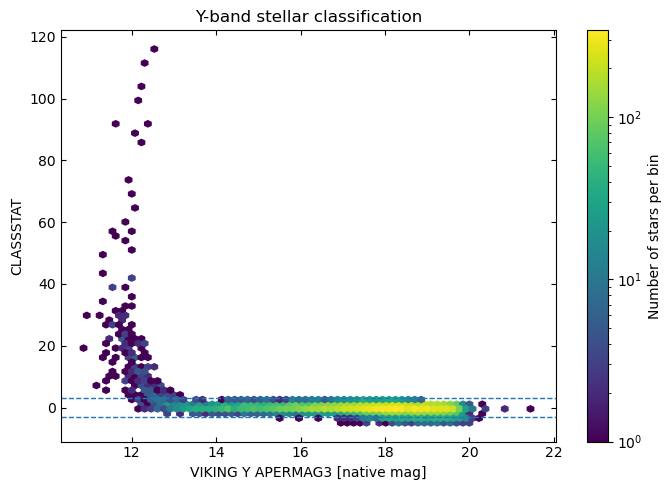

Saved: data/outputs/Monster_VIKING_Y/development_tile_y_classstat.pdf

Saved:
  data/outputs/Monster_VIKING_Y/development_tile_y_gold_matches.fits
  data/outputs/Monster_VIKING_Y/development_tile_y_quality_sample.fits
  data/outputs/Monster_VIKING_Y/development_tile_y_selection_summary.csv

Prepared variables for the next cell:
  y_gold_matches    : all Gold astrometric matches
  y_quality_sample  : clean Y calibration candidates


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning
import astropy.units as u

from IPython.display import display


# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------

GOLD_MATCH_RADIUS = 0.5 * u.arcsec
PHOTOMETRIC_MATCH_RADIUS_ARCSEC = 0.3
MONSTER_ISOLATION_RADIUS = 1.0 * u.arcsec

MINIMUM_SNR = 50.0
MAXIMUM_ABS_CLASSSTAT = 3.0

# Native VISTA Y -> true Vega -> AB:
# Y_true_Vega = Y_native - (-0.022)
# Y_AB        = Y_true_Vega + 0.600
Y_AB_MINUS_NATIVE = 0.622


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def read_table_safely(path):
    """Read a FITS table while suppressing unit warnings."""
    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            AstropyWarning,
        )
        return Table.read(path)


def float_array(column):
    """Convert a normal or masked column to float."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column,
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


def integer_array(column, fill_value=-1):
    """Convert a normal or masked integer column to int64."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(column),
            fill_value,
        ),
        dtype=np.int64,
    )


def pperrbits_array(column):
    """Preserve raw PPERRBITS=0 values hidden by FITS masking."""
    masked_column = np.ma.asarray(column)

    raw_values = np.asarray(
        np.ma.getdata(masked_column),
        dtype=np.int64,
    )

    mask = np.ma.getmaskarray(
        masked_column
    )

    if np.any(mask):
        masked_raw_values = raw_values[
            mask
        ]

        if not np.all(masked_raw_values == 0):
            raise ValueError(
                "Masked PPERRBITS entries contain nonzero raw values."
            )

    return raw_values


def safe_snr(flux, flux_error):
    """Calculate flux/error for valid positive measurements."""
    flux = np.asarray(
        flux,
        dtype=float,
    )

    flux_error = np.asarray(
        flux_error,
        dtype=float,
    )

    result = np.full(
        len(flux),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(flux)
        & np.isfinite(flux_error)
        & (flux > 0.0)
        & (flux_error > 0.0)
    )

    result[valid] = (
        flux[valid]
        / flux_error[valid]
    )

    return result


def robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return np.nan

    centre = np.median(values)

    return float(
        1.4826
        * np.median(
            np.abs(values - centre)
        )
    )


# -------------------------------------------------------------------
# Read the development VIKING catalogue
# -------------------------------------------------------------------

y_viking = read_table_safely(
    y_development_tile_path
)

source_mjd_utc = float_array(
    y_viking["MJD"]
)

finite_source_mjd = source_mjd_utc[
    np.isfinite(source_mjd_utc)
]

if len(finite_source_mjd) == 0:
    raise ValueError(
        "The development catalogue has no valid source MJD."
    )

tile_mjd_utc = float(
    np.median(finite_source_mjd)
)

tile_time_utc = Time(
    tile_mjd_utc,
    format="mjd",
    scale="utc",
)

tile_mjd_tai = float(
    tile_time_utc.tai.mjd
)

tile_epoch_jyear = float(
    tile_time_utc.jyear
)


# -------------------------------------------------------------------
# Prepare VIKING coordinates
# -------------------------------------------------------------------

viking_ra_deg = float_array(
    y_viking["RA"]
)

viking_dec_deg = float_array(
    y_viking["DEC"]
)

valid_viking_coordinates = (
    np.isfinite(viking_ra_deg)
    & np.isfinite(viking_dec_deg)
    & (viking_ra_deg >= 0.0)
    & (viking_ra_deg <= 360.0)
    & (viking_dec_deg >= -90.0)
    & (viking_dec_deg <= 90.0)
)

viking_original_indices = np.flatnonzero(
    valid_viking_coordinates
)

viking_coordinates = SkyCoord(
    ra=viking_ra_deg[
        valid_viking_coordinates
    ] * u.deg,

    dec=viking_dec_deg[
        valid_viking_coordinates
    ] * u.deg,

    frame="icrs",
)


# -------------------------------------------------------------------
# Read and deduplicate the Monster shards
# -------------------------------------------------------------------

required_monster_columns = [
    "id",
    "coord_ra",
    "coord_dec",
    "epoch",
    "pm_ra",
    "pm_dec",
    "monster_DES_z_flux",
    "monster_DES_z_fluxErr",
    "monster_DES_y_flux",
    "monster_DES_y_fluxErr",
]

monster_parts = []

for monster_path in y_development_monster_paths:
    shard = read_table_safely(
        monster_path
    )

    missing_columns = [
        name
        for name in required_monster_columns
        if name not in shard.colnames
    ]

    if missing_columns:
        raise KeyError(
            f"{monster_path.name} is missing "
            f"{missing_columns}"
        )

    monster_parts.append(
        shard[
            required_monster_columns
        ]
    )


y_monster = vstack(
    monster_parts,
    join_type="exact",
    metadata_conflicts="silent",
)

monster_ids_all = integer_array(
    y_monster["id"]
)

_, first_monster_rows = np.unique(
    monster_ids_all,
    return_index=True,
)

y_monster = y_monster[
    np.sort(first_monster_rows)
]


# -------------------------------------------------------------------
# Propagate Monster positions to the VIKING epoch
# -------------------------------------------------------------------

monster_ra_rad = float_array(
    y_monster["coord_ra"]
)

monster_dec_rad = float_array(
    y_monster["coord_dec"]
)

monster_epoch_tai_mjd = float_array(
    y_monster["epoch"]
)

monster_pmra_rad_per_year = float_array(
    y_monster["pm_ra"]
)

monster_pmdec_rad_per_year = float_array(
    y_monster["pm_dec"]
)

cos_monster_dec = np.cos(
    monster_dec_rad
)

valid_monster_astrometry = (
    np.isfinite(monster_ra_rad)
    & np.isfinite(monster_dec_rad)
    & np.isfinite(monster_epoch_tai_mjd)
    & np.isfinite(monster_pmra_rad_per_year)
    & np.isfinite(monster_pmdec_rad_per_year)
    & (monster_dec_rad >= -0.5 * np.pi)
    & (monster_dec_rad <= 0.5 * np.pi)
    & (np.abs(cos_monster_dec) > 1.0e-10)
)

valid_monster_indices = np.flatnonzero(
    valid_monster_astrometry
)

ra0 = monster_ra_rad[
    valid_monster_astrometry
]

dec0 = monster_dec_rad[
    valid_monster_astrometry
]

epoch0 = monster_epoch_tai_mjd[
    valid_monster_astrometry
]

pmra = monster_pmra_rad_per_year[
    valid_monster_astrometry
]

pmdec = monster_pmdec_rad_per_year[
    valid_monster_astrometry
]

delta_time_year = (
    tile_mjd_tai
    - epoch0
) / 365.25

propagated_ra = (
    ra0
    + pmra
    * delta_time_year
    / np.cos(dec0)
)

propagated_dec = (
    dec0
    + pmdec
    * delta_time_year
)

propagated_ra = np.mod(
    propagated_ra,
    2.0 * np.pi,
)

valid_propagated = (
    np.isfinite(propagated_ra)
    & np.isfinite(propagated_dec)
    & (propagated_dec >= -0.5 * np.pi)
    & (propagated_dec <= 0.5 * np.pi)
)

valid_monster_indices = valid_monster_indices[
    valid_propagated
]

propagated_ra = propagated_ra[
    valid_propagated
]

propagated_dec = propagated_dec[
    valid_propagated
]

monster_coordinates = SkyCoord(
    ra=propagated_ra * u.rad,
    dec=propagated_dec * u.rad,
    frame="icrs",
)


# -------------------------------------------------------------------
# Apply Monster isolation
# -------------------------------------------------------------------

_, second_monster_separation, _ = (
    match_coordinates_sky(
        monster_coordinates,
        monster_coordinates,
        nthneighbor=2,
    )
)

monster_isolated = (
    second_monster_separation
    > MONSTER_ISOLATION_RADIUS
)

isolated_monster_coordinates = (
    monster_coordinates[
        monster_isolated
    ]
)

isolated_monster_indices = (
    valid_monster_indices[
        monster_isolated
    ]
)


# -------------------------------------------------------------------
# Mutual nearest-neighbour matching
# -------------------------------------------------------------------

nearest_viking_for_monster, separation_mv, _ = (
    match_coordinates_sky(
        isolated_monster_coordinates,
        viking_coordinates,
    )
)

nearest_monster_for_viking, _, _ = (
    match_coordinates_sky(
        viking_coordinates,
        isolated_monster_coordinates,
    )
)

isolated_monster_rows = np.arange(
    len(isolated_monster_coordinates)
)

mutual = (
    nearest_monster_for_viking[
        nearest_viking_for_monster
    ]
    == isolated_monster_rows
)

gold_mask = (
    mutual
    & (
        separation_mv
        < GOLD_MATCH_RADIUS
    )
)

gold_monster_indices = (
    isolated_monster_indices[
        gold_mask
    ]
)

gold_viking_coordinate_indices = (
    nearest_viking_for_monster[
        gold_mask
    ]
)

gold_viking_indices = (
    viking_original_indices[
        gold_viking_coordinate_indices
    ]
)

gold_monster_coordinates = (
    isolated_monster_coordinates[
        gold_mask
    ]
)

gold_viking_coordinates = (
    viking_coordinates[
        gold_viking_coordinate_indices
    ]
)

gold_separation_arcsec = (
    separation_mv[
        gold_mask
    ].arcsec
)


# -------------------------------------------------------------------
# Astrometric residuals
# -------------------------------------------------------------------

delta_ra_cosdec, delta_dec = (
    gold_monster_coordinates.spherical_offsets_to(
        gold_viking_coordinates
    )
)

delta_ra_arcsec = delta_ra_cosdec.arcsec
delta_dec_arcsec = delta_dec.arcsec


# -------------------------------------------------------------------
# Read matched photometry
# -------------------------------------------------------------------

monster_id = integer_array(
    y_monster["id"][
        gold_monster_indices
    ]
)

monster_z_flux = float_array(
    y_monster["monster_DES_z_flux"][
        gold_monster_indices
    ]
)

monster_z_flux_error = float_array(
    y_monster["monster_DES_z_fluxErr"][
        gold_monster_indices
    ]
)

monster_y_flux = float_array(
    y_monster["monster_DES_y_flux"][
        gold_monster_indices
    ]
)

monster_y_flux_error = float_array(
    y_monster["monster_DES_y_fluxErr"][
        gold_monster_indices
    ]
)

viking_y_flux_adu = float_array(
    y_viking["APERFLUX3"][
        gold_viking_indices
    ]
)

viking_y_flux_error_adu = float_array(
    y_viking["APERFLUX3ERR"][
        gold_viking_indices
    ]
)

viking_y_mag_native = float_array(
    y_viking["APERMAG3"][
        gold_viking_indices
    ]
)

viking_y_mag_error = float_array(
    y_viking["APERMAG3ERR"][
        gold_viking_indices
    ]
)

viking_class = integer_array(
    y_viking["CLASS"][
        gold_viking_indices
    ],
    fill_value=999,
)

viking_classstat = float_array(
    y_viking["CLASSSTAT"][
        gold_viking_indices
    ]
)

viking_pperrbits = pperrbits_array(
    y_viking["PPERRBITS"][
        gold_viking_indices
    ]
)


# -------------------------------------------------------------------
# Derived photometry
# -------------------------------------------------------------------

viking_y_snr = safe_snr(
    viking_y_flux_adu,
    viking_y_flux_error_adu,
)

monster_z_snr = safe_snr(
    monster_z_flux,
    monster_z_flux_error,
)

monster_y_snr = safe_snr(
    monster_y_flux,
    monster_y_flux_error,
)

viking_y_mag_ab = (
    viking_y_mag_native
    + Y_AB_MINUS_NATIVE
)

viking_y_flux_njy = np.full(
    len(viking_y_mag_ab),
    np.nan,
)

valid_viking_magnitude = np.isfinite(
    viking_y_mag_ab
)

viking_y_flux_njy[
    valid_viking_magnitude
] = 10.0 ** (
    (
        31.4
        - viking_y_mag_ab[
            valid_viking_magnitude
        ]
    )
    / 2.5
)


monster_zy_colour = np.full(
    len(monster_id),
    np.nan,
)

valid_colour = (
    np.isfinite(monster_z_flux)
    & np.isfinite(monster_y_flux)
    & (monster_z_flux > 0.0)
    & (monster_y_flux > 0.0)
)

monster_zy_colour[
    valid_colour
] = (
    -2.5
    * np.log10(
        monster_z_flux[
            valid_colour
        ]
        / monster_y_flux[
            valid_colour
        ]
    )
)


y_flux_ratio = np.full(
    len(monster_id),
    np.nan,
)

valid_ratio = (
    np.isfinite(monster_y_flux)
    & np.isfinite(viking_y_flux_njy)
    & (monster_y_flux > 0.0)
    & (viking_y_flux_njy > 0.0)
)

y_flux_ratio[
    valid_ratio
] = (
    monster_y_flux[
        valid_ratio
    ]
    / viking_y_flux_njy[
        valid_ratio
    ]
)


# -------------------------------------------------------------------
# Construct Gold and quality tables
# -------------------------------------------------------------------

y_gold_matches = Table()

y_gold_matches["monster_id"] = monster_id
y_gold_matches["monster_original_index"] = gold_monster_indices
y_gold_matches["viking_original_index"] = gold_viking_indices

y_gold_matches["separation_arcsec"] = gold_separation_arcsec
y_gold_matches["delta_ra_cosdec_arcsec"] = delta_ra_arcsec
y_gold_matches["delta_dec_arcsec"] = delta_dec_arcsec

y_gold_matches["tile_epoch_utc_mjd"] = np.full(
    len(monster_id),
    tile_mjd_utc,
)

y_gold_matches["tile_epoch_jyear"] = np.full(
    len(monster_id),
    tile_epoch_jyear,
)

y_gold_matches["viking_y_mag_native"] = viking_y_mag_native
y_gold_matches["viking_y_mag_ab"] = viking_y_mag_ab
y_gold_matches["viking_y_flux_njy"] = viking_y_flux_njy
y_gold_matches["viking_y_snr"] = viking_y_snr

y_gold_matches["viking_class"] = viking_class
y_gold_matches["viking_classstat"] = viking_classstat
y_gold_matches["viking_pperrbits"] = viking_pperrbits

y_gold_matches["monster_z_flux_njy"] = monster_z_flux
y_gold_matches["monster_z_fluxerr_njy"] = monster_z_flux_error
y_gold_matches["monster_y_flux_njy"] = monster_y_flux
y_gold_matches["monster_y_fluxerr_njy"] = monster_y_flux_error

y_gold_matches["monster_z_snr"] = monster_z_snr
y_gold_matches["monster_y_snr"] = monster_y_snr

y_gold_matches["monster_zy_colour"] = monster_zy_colour
y_gold_matches["monster_y_over_vista_y"] = y_flux_ratio


finite_photometry = (
    np.isfinite(monster_zy_colour)
    & np.isfinite(y_flux_ratio)
    & (y_flux_ratio > 0.0)
)

secure_separation = (
    gold_separation_arcsec
    < PHOTOMETRIC_MATCH_RADIUS_ARCSEC
)

stellar = (
    viking_class == -1
)

stable_classstat = (
    np.isfinite(viking_classstat)
    & (
        np.abs(viking_classstat)
        < MAXIMUM_ABS_CLASSSTAT
    )
)

high_snr = (
    (viking_y_snr >= MINIMUM_SNR)
    & (monster_z_snr >= MINIMUM_SNR)
    & (monster_y_snr >= MINIMUM_SNR)
)

clean_flags = (
    viking_pperrbits == 0
)


selection_steps = [
    (
        "Gold matches",
        np.ones(
            len(monster_id),
            dtype=bool,
        ),
    ),
    (
        "Finite colour and ratio",
        finite_photometry,
    ),
    (
        "Separation < 0.3 arcsec",
        finite_photometry
        & secure_separation,
    ),
    (
        "CLASS = -1",
        finite_photometry
        & secure_separation
        & stellar,
    ),
    (
        "Absolute CLASSSTAT < 3",
        finite_photometry
        & secure_separation
        & stellar
        & stable_classstat,
    ),
    (
        "S/N >= 50 in all bands",
        finite_photometry
        & secure_separation
        & stellar
        & stable_classstat
        & high_snr,
    ),
    (
        "PPERRBITS = 0",
        finite_photometry
        & secure_separation
        & stellar
        & stable_classstat
        & high_snr
        & clean_flags,
    ),
]


selection_summary = pd.DataFrame(
    [
        {
            "stage": stage_name,
            "number_remaining": int(
                np.count_nonzero(stage_mask)
            ),
            "fraction_of_gold": float(
                np.mean(stage_mask)
            ),
        }
        for stage_name, stage_mask
        in selection_steps
    ]
)

display(
    selection_summary
)


y_quality_mask = selection_steps[-1][1]

y_quality_sample = y_gold_matches[
    y_quality_mask
].copy()


# -------------------------------------------------------------------
# Print summary
# -------------------------------------------------------------------

selected_colour = float_array(
    y_quality_sample[
        "monster_zy_colour"
    ]
)

selected_ratio = float_array(
    y_quality_sample[
        "monster_y_over_vista_y"
    ]
)

selected_magnitude = float_array(
    y_quality_sample[
        "viking_y_mag_native"
    ]
)


print("\n" + "=" * 72)
print("Y-BAND DEVELOPMENT-TILE SAMPLE")
print("=" * 72)

print(
    f"VIKING catalogue rows       : "
    f"{len(y_viking):,}"
)

print(
    f"Unique Monster rows         : "
    f"{len(y_monster):,}"
)

print(
    f"Valid Monster PM sources    : "
    f"{np.count_nonzero(valid_monster_astrometry):,}"
)

print(
    f"Isolated Monster sources    : "
    f"{np.count_nonzero(monster_isolated):,}"
)

print(
    f"Mutual nearest neighbours   : "
    f"{np.count_nonzero(mutual):,}"
)

print(
    f"Gold matches within 0.5     : "
    f"{len(y_gold_matches):,}"
)

print(
    f"Quality calibration stars   : "
    f"{len(y_quality_sample):,}"
)

print(
    f"Median Gold separation      : "
    f"{np.median(gold_separation_arcsec):.4f} arcsec"
)

print(
    f"Median residual RA          : "
    f"{np.median(delta_ra_arcsec):+.4f} arcsec"
)

print(
    f"Median residual Dec         : "
    f"{np.median(delta_dec_arcsec):+.4f} arcsec"
)


if len(y_quality_sample) > 0:
    print(
        f"Colour 1st--99th percentile : "
        f"{np.percentile(selected_colour, 1):.4f} to "
        f"{np.percentile(selected_colour, 99):.4f}"
    )

    print(
        f"Native Y magnitude range    : "
        f"{np.min(selected_magnitude):.3f} to "
        f"{np.max(selected_magnitude):.3f}"
    )

    print(
        f"Median Y flux ratio         : "
        f"{np.median(selected_ratio):.6f}"
    )

    print(
        f"Y flux-ratio NMAD           : "
        f"{robust_nmad(selected_ratio):.6f}"
    )


# -------------------------------------------------------------------
# Plot the preliminary colour relation
# -------------------------------------------------------------------

if len(y_quality_sample) > 0:

    ratio_low = float(
        np.percentile(
            selected_ratio,
            0.5,
        )
    )

    ratio_high = float(
        np.percentile(
            selected_ratio,
            99.5,
        )
    )

    figure, axis = plt.subplots(
        figsize=(7, 5),
    )

    density = axis.hexbin(
        selected_colour,
        selected_ratio,
        gridsize=70,
        mincnt=1,
        bins="log",
    )

    axis.set_xlabel(
        "Monster (z - y) [mag]"
    )

    axis.set_ylabel(
        "Monster_y / VISTA_Y"
    )

    axis.set_ylim(
        ratio_low,
        ratio_high,
    )

    axis.set_title(
        "Development-tile Y colour relation"
    )

    axis.tick_params(
        direction="in",
        top=True,
        right=True,
    )

    colourbar = figure.colorbar(
        density,
        ax=axis,
    )

    colourbar.set_label(
        "Number of stars per bin"
    )

    figure.tight_layout()

    relation_path = (
        Y_OUTPUT_DIR
        / "development_tile_y_colour_relation.pdf"
    )

    figure.savefig(
        relation_path,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved: {relation_path}"
    )


# -------------------------------------------------------------------
# Plot CLASSSTAT against native Y magnitude
# -------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(7, 5),
)

valid_class_plot = (
    np.isfinite(viking_y_mag_native)
    & np.isfinite(viking_classstat)
    & (viking_class == -1)
)

density = axis.hexbin(
    viking_y_mag_native[
        valid_class_plot
    ],
    viking_classstat[
        valid_class_plot
    ],
    gridsize=70,
    mincnt=1,
    bins="log",
)

axis.axhline(
    -MAXIMUM_ABS_CLASSSTAT,
    linestyle="--",
    linewidth=1.0,
)

axis.axhline(
    MAXIMUM_ABS_CLASSSTAT,
    linestyle="--",
    linewidth=1.0,
)

axis.set_xlabel(
    "VIKING Y APERMAG3 [native mag]"
)

axis.set_ylabel(
    "CLASSSTAT"
)

axis.set_title(
    "Y-band stellar classification"
)

axis.tick_params(
    direction="in",
    top=True,
    right=True,
)

colourbar = figure.colorbar(
    density,
    ax=axis,
)

colourbar.set_label(
    "Number of stars per bin"
)

figure.tight_layout()

classstat_path = (
    Y_OUTPUT_DIR
    / "development_tile_y_classstat.pdf"
)

figure.savefig(
    classstat_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {classstat_path}"
)


# -------------------------------------------------------------------
# Save the development products
# -------------------------------------------------------------------

gold_path = (
    Y_OUTPUT_DIR
    / "development_tile_y_gold_matches.fits"
)

quality_path = (
    Y_OUTPUT_DIR
    / "development_tile_y_quality_sample.fits"
)

summary_path = (
    Y_OUTPUT_DIR
    / "development_tile_y_selection_summary.csv"
)

y_gold_matches.write(
    gold_path,
    format="fits",
    overwrite=True,
)

y_quality_sample.write(
    quality_path,
    format="fits",
    overwrite=True,
)

selection_summary.to_csv(
    summary_path,
    index=False,
)


print("\nSaved:")
print(f"  {gold_path}")
print(f"  {quality_path}")
print(f"  {summary_path}")

print("\nPrepared variables for the next cell:")
print(
    "  y_gold_matches    : all Gold astrometric matches"
)

print(
    "  y_quality_sample  : clean Y calibration candidates"
)

### Result

The development tile produces 18,743 Gold astrometric matches, with a median
separation of 0.127 arcsec. After applying the photometric-quality criteria,
743 calibration stars remain.

The selected sources show a clear decreasing relation between Monster
z - y colour and the Monster_y / VISTA_Y flux ratio. The stellar
classification is stable over the main magnitude range, but sources brighter
than approximately native Y = 13 show less reliable CLASSSTAT values and are
excluded from the preliminary spline test.

## 3. Test the Y-band spline on the development tile

A preliminary magnitude requirement of

    13 < Y_native < 19

is applied to remove the unstable bright-source regime. The upper limit is
only a safety boundary; the signal-to-noise requirements already restrict
this development sample to substantially brighter magnitudes.

The remaining stars are divided deterministically into fitting and validation
samples using their Monster identifiers. The preliminary spline is tested
over

    -0.05 <= Monster (z - y) <= 0.13

using seven colour nodes.

using six colour nodes.

Robust median flux ratios are measured around each node using the fitting
sample. The withheld validation stars are then used to check the residual
scatter and any remaining dependence on colour or magnitude.

The final colour range and nodes will be selected from the combined 87-tile
sample.

PRELIMINARY Y-BAND SPLINE SAMPLE
Quality stars before magnitude cut : 743
Stars after magnitude cut           : 717
Stars inside node range             : 621
Fitting stars                       : 502
Validation stars                    : 119

Preliminary Y-band nodes
------------------------


,node_colour,bin_lower_edge,bin_upper_edge,number_before_clipping,number_after_clipping,median_ratio,ratio_nmad,node_uncertainty
0,-0.05,-0.065,-0.035,72,69,0.912101,0.015517,0.002341
1,-0.02,-0.035,-0.005,142,142,0.915921,0.020282,0.002133
2,0.01,-0.005,0.025,70,70,0.903932,0.018374,0.002752
3,0.04,0.025,0.055,65,64,0.901157,0.020535,0.003217
4,0.07,0.055,0.085,72,72,0.890441,0.018468,0.002728
5,0.10,0.085,0.115,56,55,0.881560,0.019701,0.003329
6,0.13,0.115,0.145,25,25,0.879461,0.016286,0.004082



PRELIMINARY Y-BAND VALIDATION
Validation sources             : 119
Median ratio residual          : -0.000576
Residual NMAD                  : 0.020103
Fractional residual NMAD       : 2.206 per cent
Residual-colour Spearman rho   : -0.1195
Residual-colour p-value        : 1.956e-01
Residual-magnitude Spearman rho: +0.2276
Residual-magnitude p-value     : 1.279e-02


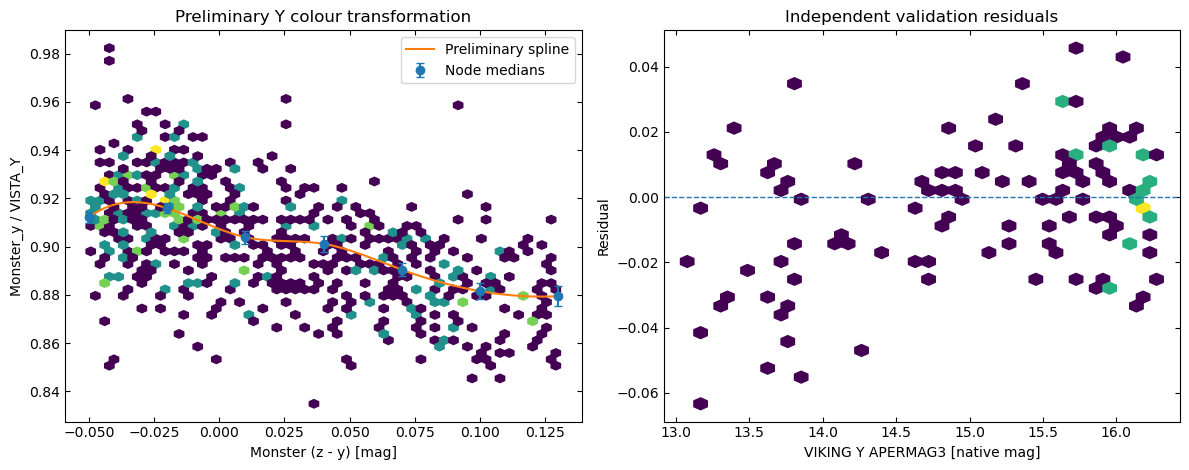


Saved: data/outputs/Monster_VIKING_Y/development_tile_y_preliminary_spline.pdf
Saved: data/outputs/Monster_VIKING_Y/development_tile_y_preliminary_nodes.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import make_interp_spline
from scipy.stats import spearmanr
from IPython.display import display


# -------------------------------------------------------------------
# Preliminary Y-band spline configuration
# -------------------------------------------------------------------

Y_MIN_NATIVE_MAG = 13.0
Y_MAX_NATIVE_MAG = 19.0

PRELIMINARY_Y_NODES = np.linspace(
    -0.05,
    0.13,
    7,
)

MINIMUM_STARS_PER_NODE = 20
CLIP_THRESHOLD = 3.0
MAXIMUM_CLIP_ITERATIONS = 10


# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

def y_float_array(column):
    """Convert an ordinary or masked column to float."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column,
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


def y_robust_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return np.nan

    centre = np.median(
        values
    )

    return float(
        1.4826
        * np.median(
            np.abs(
                values - centre
            )
        )
    )


def y_iterative_clip(values):
    """Return values retained by iterative median/NMAD clipping."""
    values = np.asarray(
        values,
        dtype=float,
    )

    retained = values[
        np.isfinite(values)
    ]

    for _ in range(
        MAXIMUM_CLIP_ITERATIONS
    ):
        if len(retained) < 3:
            break

        centre = np.median(
            retained
        )

        scatter = y_robust_nmad(
            retained
        )

        if (
            not np.isfinite(scatter)
            or scatter <= 0.0
        ):
            break

        keep = (
            np.abs(
                retained - centre
            )
            <= CLIP_THRESHOLD * scatter
        )

        if np.all(keep):
            break

        retained = retained[
            keep
        ]

    return retained


# -------------------------------------------------------------------
# Read the development-tile quantities
# -------------------------------------------------------------------

y_test_colour = y_float_array(
    y_quality_sample[
        "monster_zy_colour"
    ]
)

y_test_ratio = y_float_array(
    y_quality_sample[
        "monster_y_over_vista_y"
    ]
)

y_test_magnitude = y_float_array(
    y_quality_sample[
        "viking_y_mag_native"
    ]
)

y_test_monster_id = np.asarray(
    y_quality_sample[
        "monster_id"
    ],
    dtype=np.int64,
)


valid_y_test = (
    np.isfinite(y_test_colour)
    & np.isfinite(y_test_ratio)
    & np.isfinite(y_test_magnitude)
    & (y_test_ratio > 0.0)
    & (
        y_test_magnitude
        > Y_MIN_NATIVE_MAG
    )
    & (
        y_test_magnitude
        < Y_MAX_NATIVE_MAG
    )
)


y_test_colour = y_test_colour[
    valid_y_test
]

y_test_ratio = y_test_ratio[
    valid_y_test
]

y_test_magnitude = y_test_magnitude[
    valid_y_test
]

y_test_monster_id = y_test_monster_id[
    valid_y_test
]


# -------------------------------------------------------------------
# Define fitting and validation samples
# -------------------------------------------------------------------

inside_node_range = (
    y_test_colour
    >= PRELIMINARY_Y_NODES[0]
) & (
    y_test_colour
    <= PRELIMINARY_Y_NODES[-1]
)

validation_mask = (
    inside_node_range
    & (
        np.mod(
            y_test_monster_id,
            5,
        )
        == 0
    )
)

fitting_mask = (
    inside_node_range
    & ~validation_mask
)


print("=" * 72)
print("PRELIMINARY Y-BAND SPLINE SAMPLE")
print("=" * 72)

print(
    f"Quality stars before magnitude cut : "
    f"{len(y_quality_sample):,}"
)

print(
    f"Stars after magnitude cut           : "
    f"{len(y_test_colour):,}"
)

print(
    f"Stars inside node range             : "
    f"{np.count_nonzero(inside_node_range):,}"
)

print(
    f"Fitting stars                       : "
    f"{np.count_nonzero(fitting_mask):,}"
)

print(
    f"Validation stars                    : "
    f"{np.count_nonzero(validation_mask):,}"
)


# -------------------------------------------------------------------
# Construct bins centred on the spline nodes
# -------------------------------------------------------------------

node_midpoints = 0.5 * (
    PRELIMINARY_Y_NODES[:-1]
    + PRELIMINARY_Y_NODES[1:]
)

node_edges = np.concatenate(
    [
        [
            PRELIMINARY_Y_NODES[0]
            - (
                node_midpoints[0]
                - PRELIMINARY_Y_NODES[0]
            )
        ],
        node_midpoints,
        [
            PRELIMINARY_Y_NODES[-1]
            + (
                PRELIMINARY_Y_NODES[-1]
                - node_midpoints[-1]
            )
        ],
    ]
)


# -------------------------------------------------------------------
# Calculate robust fitting-node values
# -------------------------------------------------------------------

node_values = np.full(
    len(PRELIMINARY_Y_NODES),
    np.nan,
)

node_scatter = np.full(
    len(PRELIMINARY_Y_NODES),
    np.nan,
)

node_uncertainty = np.full(
    len(PRELIMINARY_Y_NODES),
    np.nan,
)

node_number_before = np.zeros(
    len(PRELIMINARY_Y_NODES),
    dtype=int,
)

node_number_after = np.zeros(
    len(PRELIMINARY_Y_NODES),
    dtype=int,
)


for node_index in range(
    len(PRELIMINARY_Y_NODES)
):
    in_node_bin = (
        fitting_mask
        & (
            y_test_colour
            >= node_edges[node_index]
        )
        & (
            y_test_colour
            < node_edges[node_index + 1]
        )
    )

    if node_index == len(
        PRELIMINARY_Y_NODES
    ) - 1:
        in_node_bin = (
            fitting_mask
            & (
                y_test_colour
                >= node_edges[node_index]
            )
            & (
                y_test_colour
                <= node_edges[node_index + 1]
            )
        )

    node_ratios = y_test_ratio[
        in_node_bin
    ]

    node_number_before[
        node_index
    ] = len(
        node_ratios
    )

    clipped_ratios = y_iterative_clip(
        node_ratios
    )

    node_number_after[
        node_index
    ] = len(
        clipped_ratios
    )

    if (
        len(clipped_ratios)
        < MINIMUM_STARS_PER_NODE
    ):
        continue

    node_values[
        node_index
    ] = float(
        np.median(
            clipped_ratios
        )
    )

    node_scatter[
        node_index
    ] = y_robust_nmad(
        clipped_ratios
    )

    node_uncertainty[
        node_index
    ] = (
        1.2533
        * node_scatter[
            node_index
        ]
        / np.sqrt(
            len(
                clipped_ratios
            )
        )
    )


preliminary_y_node_table = pd.DataFrame(
    {
        "node_colour":
            PRELIMINARY_Y_NODES,

        "bin_lower_edge":
            node_edges[:-1],

        "bin_upper_edge":
            node_edges[1:],

        "number_before_clipping":
            node_number_before,

        "number_after_clipping":
            node_number_after,

        "median_ratio":
            node_values,

        "ratio_nmad":
            node_scatter,

        "node_uncertainty":
            node_uncertainty,
    }
)


print("\nPreliminary Y-band nodes")
print("------------------------")

display(
    preliminary_y_node_table
)


unsupported_nodes = (
    ~np.isfinite(
        node_values
    )
)

if np.any(
    unsupported_nodes
):
    raise RuntimeError(
        "Insufficient stars at preliminary nodes:\n"
        f"{PRELIMINARY_Y_NODES[unsupported_nodes]}"
    )


# -------------------------------------------------------------------
# Fit and evaluate the preliminary spline
# -------------------------------------------------------------------

preliminary_y_spline = make_interp_spline(
    PRELIMINARY_Y_NODES,
    node_values,
    k=3,
)

smooth_y_colour = np.linspace(
    PRELIMINARY_Y_NODES[0],
    PRELIMINARY_Y_NODES[-1],
    500,
)

smooth_y_ratio = preliminary_y_spline(
    smooth_y_colour
)


model_ratio = np.full(
    len(y_test_ratio),
    np.nan,
)

model_ratio[
    inside_node_range
] = preliminary_y_spline(
    y_test_colour[
        inside_node_range
    ]
)

ratio_residual = (
    y_test_ratio
    - model_ratio
)


# -------------------------------------------------------------------
# Validation statistics
# -------------------------------------------------------------------

validation_colour = y_test_colour[
    validation_mask
]

validation_magnitude = y_test_magnitude[
    validation_mask
]

validation_residual = ratio_residual[
    validation_mask
]

validation_model = model_ratio[
    validation_mask
]


valid_validation = (
    np.isfinite(
        validation_residual
    )
    & np.isfinite(
        validation_model
    )
    & (
        validation_model > 0.0
    )
)

validation_fractional_residual = (
    validation_residual[
        valid_validation
    ]
    / validation_model[
        valid_validation
    ]
)


colour_correlation = spearmanr(
    validation_colour[
        valid_validation
    ],
    validation_residual[
        valid_validation
    ],
)

magnitude_correlation = spearmanr(
    validation_magnitude[
        valid_validation
    ],
    validation_residual[
        valid_validation
    ],
)


print("\n" + "=" * 72)
print("PRELIMINARY Y-BAND VALIDATION")
print("=" * 72)

print(
    f"Validation sources             : "
    f"{np.count_nonzero(valid_validation):,}"
)

print(
    f"Median ratio residual          : "
    f"{np.median(validation_residual[valid_validation]):+.6f}"
)

print(
    f"Residual NMAD                  : "
    f"{y_robust_nmad(validation_residual[valid_validation]):.6f}"
)

print(
    f"Fractional residual NMAD       : "
    f"{100.0 * y_robust_nmad(validation_fractional_residual):.3f} per cent"
)

print(
    f"Residual-colour Spearman rho   : "
    f"{colour_correlation.statistic:+.4f}"
)

print(
    f"Residual-colour p-value        : "
    f"{colour_correlation.pvalue:.3e}"
)

print(
    f"Residual-magnitude Spearman rho: "
    f"{magnitude_correlation.statistic:+.4f}"
)

print(
    f"Residual-magnitude p-value     : "
    f"{magnitude_correlation.pvalue:.3e}"
)


# -------------------------------------------------------------------
# Diagnostic plots
# -------------------------------------------------------------------

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
)

relation_axis = axes[0]
residual_axis = axes[1]


relation_density = relation_axis.hexbin(
    y_test_colour[
        inside_node_range
    ],
    y_test_ratio[
        inside_node_range
    ],
    gridsize=50,
    mincnt=1,
    bins="log",
)

relation_axis.errorbar(
    PRELIMINARY_Y_NODES,
    node_values,
    yerr=node_uncertainty,
    fmt="o",
    capsize=3,
    label="Node medians",
)

relation_axis.plot(
    smooth_y_colour,
    smooth_y_ratio,
    linewidth=1.5,
    label="Preliminary spline",
)

relation_axis.set_xlabel(
    "Monster (z - y) [mag]"
)

relation_axis.set_ylabel(
    "Monster_y / VISTA_Y"
)

relation_axis.set_title(
    "Preliminary Y colour transformation"
)

relation_axis.legend()

relation_axis.tick_params(
    direction="in",
    top=True,
    right=True,
)


residual_density = residual_axis.hexbin(
    validation_magnitude[
        valid_validation
    ],
    validation_residual[
        valid_validation
    ],
    gridsize=35,
    mincnt=1,
    bins="log",
)

residual_axis.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

residual_axis.set_xlabel(
    "VIKING Y APERMAG3 [native mag]"
)

residual_axis.set_ylabel(
    "Residual"
)

residual_axis.set_title(
    "Independent validation residuals"
)

residual_axis.tick_params(
    direction="in",
    top=True,
    right=True,
)


figure.tight_layout()

preliminary_plot_path = (
    Y_OUTPUT_DIR
    / "development_tile_y_preliminary_spline.pdf"
)

figure.savefig(
    preliminary_plot_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"\nSaved: {preliminary_plot_path}"
)


# -------------------------------------------------------------------
# Save preliminary results
# -------------------------------------------------------------------

preliminary_node_path = (
    Y_OUTPUT_DIR
    / "development_tile_y_preliminary_nodes.csv"
)

preliminary_y_node_table.to_csv(
    preliminary_node_path,
    index=False,
)

print(
    f"Saved: {preliminary_node_path}"
)

### Result

After applying the magnitude and colour limits, 646 stars remain inside the
preliminary spline range. Of these, 522 are used for fitting and 124 for
independent validation.

All seven colour nodes are sufficiently populated. The measured ratio
decreases from approximately 0.912 at Monster z - y = -0.05 to 0.879 at
z - y = 0.13. The validation residuals remain centred near zero without an
obvious strong dependence on magnitude.

The slight structure at the blue end is not interpreted from a single tile.
The final relation will be determined from the complete 87-catalogue sample.

## 4. Construct the combined Y-band calibration sample

The validated matching and quality-selection procedure is now applied to all
87 VIKING Y-band catalogues.

Each catalogue is processed at its recorded observing epoch. The selected
sample requires mutual nearest-neighbour matching, Monster isolation, a
separation below 0.3 arcsec, stellar classification, clean flags, absolute
CLASSSTAT below 3, signal-to-noise ratio of at least 50 in VIKING Y and
Monster DES z and y, and:

    13 < Y_native < 19

Both the complete observation-level sample and one best measurement per
Monster source are saved. For sources measured in overlapping tiles, the
measurement with the highest VIKING Y signal-to-noise ratio is retained.

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning
import astropy.units as u


# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------

Y_GOLD_RADIUS = 0.5 * u.arcsec
Y_CALIBRATION_RADIUS_ARCSEC = 0.3
Y_ISOLATION_RADIUS = 1.0 * u.arcsec

Y_MINIMUM_SNR = 50.0
Y_MAXIMUM_ABS_CLASSSTAT = 3.0

Y_MINIMUM_NATIVE_MAG = 13.0
Y_MAXIMUM_NATIVE_MAG = 19.0

Y_AB_MINUS_NATIVE = 0.622


# -------------------------------------------------------------------
# Process one Y-band catalogue
# -------------------------------------------------------------------

def process_viking_y_tile(viking_path):
    """Return selected calibration stars and summary for one tile."""

    monster_directory = (
        Y_MONSTER_ROOT
        / viking_path.stem
    )

    monster_paths = sorted(
        monster_directory.glob("*.fits")
    )

    if not monster_paths:
        raise FileNotFoundError(
            f"No Monster shards found for {viking_path.name}"
        )


    # ---------------------------------------------------------------
    # Read VIKING and determine the observing epoch
    # ---------------------------------------------------------------

    viking_tile = read_table_safely(
        viking_path
    )

    source_mjd = float_array(
        viking_tile["MJD"]
    )

    finite_mjd = source_mjd[
        np.isfinite(source_mjd)
    ]

    if len(finite_mjd) == 0:
        raise ValueError(
            f"{viking_path.name} has no finite source MJD."
        )

    tile_mjd_utc = float(
        np.median(finite_mjd)
    )

    tile_time_utc = Time(
        tile_mjd_utc,
        format="mjd",
        scale="utc",
    )

    tile_mjd_tai = float(
        tile_time_utc.tai.mjd
    )

    tile_epoch_jyear = float(
        tile_time_utc.jyear
    )


    # ---------------------------------------------------------------
    # Prepare VIKING coordinates
    # ---------------------------------------------------------------

    viking_ra_deg = float_array(
        viking_tile["RA"]
    )

    viking_dec_deg = float_array(
        viking_tile["DEC"]
    )

    valid_viking_coordinates = (
        np.isfinite(viking_ra_deg)
        & np.isfinite(viking_dec_deg)
        & (viking_ra_deg >= 0.0)
        & (viking_ra_deg <= 360.0)
        & (viking_dec_deg >= -90.0)
        & (viking_dec_deg <= 90.0)
    )

    viking_original_indices = np.flatnonzero(
        valid_viking_coordinates
    )

    viking_coordinates = SkyCoord(
        ra=viking_ra_deg[
            valid_viking_coordinates
        ] * u.deg,

        dec=viking_dec_deg[
            valid_viking_coordinates
        ] * u.deg,

        frame="icrs",
    )

    if len(viking_coordinates) == 0:
        raise ValueError(
            f"{viking_path.name} has no valid coordinates."
        )

    median_dec = float(
        np.nanmedian(
            viking_dec_deg[
                valid_viking_coordinates
            ]
        )
    )

    region = (
        "southern"
        if median_dec < -20.0
        else "northern_equatorial"
    )


    # ---------------------------------------------------------------
    # Read and deduplicate Monster shards
    # ---------------------------------------------------------------

    monster_columns = [
        "id",
        "coord_ra",
        "coord_dec",
        "epoch",
        "pm_ra",
        "pm_dec",
        "monster_DES_z_flux",
        "monster_DES_z_fluxErr",
        "monster_DES_y_flux",
        "monster_DES_y_fluxErr",
    ]

    monster_parts = []

    for monster_path in monster_paths:
        shard = read_table_safely(
            monster_path
        )

        missing_columns = [
            name
            for name in monster_columns
            if name not in shard.colnames
        ]

        if missing_columns:
            raise KeyError(
                f"{monster_path.name} is missing "
                f"{missing_columns}"
            )

        monster_parts.append(
            shard[monster_columns]
        )


    monster_tile = vstack(
        monster_parts,
        join_type="exact",
        metadata_conflicts="silent",
    )

    monster_ids = integer_array(
        monster_tile["id"]
    )

    _, first_rows = np.unique(
        monster_ids,
        return_index=True,
    )

    monster_tile = monster_tile[
        np.sort(first_rows)
    ]


    # ---------------------------------------------------------------
    # Propagate Monster to the VIKING epoch
    # ---------------------------------------------------------------

    monster_ra = float_array(
        monster_tile["coord_ra"]
    )

    monster_dec = float_array(
        monster_tile["coord_dec"]
    )

    monster_epoch = float_array(
        monster_tile["epoch"]
    )

    monster_pmra = float_array(
        monster_tile["pm_ra"]
    )

    monster_pmdec = float_array(
        monster_tile["pm_dec"]
    )

    cos_dec = np.cos(
        monster_dec
    )

    valid_monster = (
        np.isfinite(monster_ra)
        & np.isfinite(monster_dec)
        & np.isfinite(monster_epoch)
        & np.isfinite(monster_pmra)
        & np.isfinite(monster_pmdec)
        & (monster_dec >= -0.5 * np.pi)
        & (monster_dec <= 0.5 * np.pi)
        & (np.abs(cos_dec) > 1.0e-10)
    )

    valid_monster_indices = np.flatnonzero(
        valid_monster
    )

    ra0 = monster_ra[
        valid_monster
    ]

    dec0 = monster_dec[
        valid_monster
    ]

    epoch0 = monster_epoch[
        valid_monster
    ]

    pmra0 = monster_pmra[
        valid_monster
    ]

    pmdec0 = monster_pmdec[
        valid_monster
    ]

    delta_year = (
        tile_mjd_tai
        - epoch0
    ) / 365.25

    propagated_ra = (
        ra0
        + pmra0
        * delta_year
        / np.cos(dec0)
    )

    propagated_dec = (
        dec0
        + pmdec0
        * delta_year
    )

    propagated_ra = np.mod(
        propagated_ra,
        2.0 * np.pi,
    )

    valid_propagated = (
        np.isfinite(propagated_ra)
        & np.isfinite(propagated_dec)
        & (propagated_dec >= -0.5 * np.pi)
        & (propagated_dec <= 0.5 * np.pi)
    )

    valid_monster_indices = valid_monster_indices[
        valid_propagated
    ]

    propagated_ra = propagated_ra[
        valid_propagated
    ]

    propagated_dec = propagated_dec[
        valid_propagated
    ]

    monster_coordinates = SkyCoord(
        ra=propagated_ra * u.rad,
        dec=propagated_dec * u.rad,
        frame="icrs",
    )

    if len(monster_coordinates) < 2:
        raise ValueError(
            f"{viking_path.name} has insufficient Monster sources."
        )


    # ---------------------------------------------------------------
    # Isolation and mutual nearest-neighbour matching
    # ---------------------------------------------------------------

    _, second_separation, _ = match_coordinates_sky(
        monster_coordinates,
        monster_coordinates,
        nthneighbor=2,
    )

    isolated = (
        second_separation
        > Y_ISOLATION_RADIUS
    )

    isolated_coordinates = (
        monster_coordinates[
            isolated
        ]
    )

    isolated_monster_indices = (
        valid_monster_indices[
            isolated
        ]
    )

    nearest_viking, separation_mv, _ = (
        match_coordinates_sky(
            isolated_coordinates,
            viking_coordinates,
        )
    )

    nearest_monster, _, _ = (
        match_coordinates_sky(
            viking_coordinates,
            isolated_coordinates,
        )
    )

    isolated_rows = np.arange(
        len(isolated_coordinates)
    )

    mutual = (
        nearest_monster[
            nearest_viking
        ]
        == isolated_rows
    )

    gold = (
        mutual
        & (
            separation_mv
            < Y_GOLD_RADIUS
        )
    )

    gold_monster_indices = (
        isolated_monster_indices[
            gold
        ]
    )

    gold_viking_coordinate_indices = (
        nearest_viking[
            gold
        ]
    )

    gold_viking_indices = (
        viking_original_indices[
            gold_viking_coordinate_indices
        ]
    )

    gold_monster_coordinates = (
        isolated_coordinates[
            gold
        ]
    )

    gold_viking_coordinates = (
        viking_coordinates[
            gold_viking_coordinate_indices
        ]
    )

    gold_separation = (
        separation_mv[
            gold
        ].arcsec
    )

    if len(gold_monster_indices) == 0:
        raise ValueError(
            f"{viking_path.name} produced no Gold matches."
        )


    # ---------------------------------------------------------------
    # Coordinate residuals
    # ---------------------------------------------------------------

    delta_ra, delta_dec = (
        gold_monster_coordinates.spherical_offsets_to(
            gold_viking_coordinates
        )
    )

    delta_ra_arcsec = delta_ra.arcsec
    delta_dec_arcsec = delta_dec.arcsec


    # ---------------------------------------------------------------
    # Matched Monster photometry
    # ---------------------------------------------------------------

    monster_id = integer_array(
        monster_tile["id"][
            gold_monster_indices
        ]
    )

    monster_z_flux = float_array(
        monster_tile[
            "monster_DES_z_flux"
        ][
            gold_monster_indices
        ]
    )

    monster_z_flux_error = float_array(
        monster_tile[
            "monster_DES_z_fluxErr"
        ][
            gold_monster_indices
        ]
    )

    monster_y_flux = float_array(
        monster_tile[
            "monster_DES_y_flux"
        ][
            gold_monster_indices
        ]
    )

    monster_y_flux_error = float_array(
        monster_tile[
            "monster_DES_y_fluxErr"
        ][
            gold_monster_indices
        ]
    )


    # ---------------------------------------------------------------
    # Matched VIKING photometry
    # ---------------------------------------------------------------

    viking_y_flux_adu = float_array(
        viking_tile["APERFLUX3"][
            gold_viking_indices
        ]
    )

    viking_y_flux_error_adu = float_array(
        viking_tile["APERFLUX3ERR"][
            gold_viking_indices
        ]
    )

    viking_y_mag_native = float_array(
        viking_tile["APERMAG3"][
            gold_viking_indices
        ]
    )

    viking_y_mag_error = float_array(
        viking_tile["APERMAG3ERR"][
            gold_viking_indices
        ]
    )

    viking_class = integer_array(
        viking_tile["CLASS"][
            gold_viking_indices
        ],
        fill_value=999,
    )

    viking_classstat = float_array(
        viking_tile["CLASSSTAT"][
            gold_viking_indices
        ]
    )

    viking_pperrbits = pperrbits_array(
        viking_tile["PPERRBITS"][
            gold_viking_indices
        ]
    )


    # ---------------------------------------------------------------
    # Derived quantities
    # ---------------------------------------------------------------

    viking_y_snr = safe_snr(
        viking_y_flux_adu,
        viking_y_flux_error_adu,
    )

    monster_z_snr = safe_snr(
        monster_z_flux,
        monster_z_flux_error,
    )

    monster_y_snr = safe_snr(
        monster_y_flux,
        monster_y_flux_error,
    )

    viking_y_mag_ab = (
        viking_y_mag_native
        + Y_AB_MINUS_NATIVE
    )

    viking_y_flux_njy = np.full(
        len(viking_y_mag_ab),
        np.nan,
    )

    valid_y_mag = np.isfinite(
        viking_y_mag_ab
    )

    viking_y_flux_njy[
        valid_y_mag
    ] = 10.0 ** (
        (
            31.4
            - viking_y_mag_ab[
                valid_y_mag
            ]
        )
        / 2.5
    )

    viking_y_flux_error_njy = np.full(
        len(viking_y_mag_ab),
        np.nan,
    )

    valid_y_mag_error = (
        valid_y_mag
        & np.isfinite(viking_y_mag_error)
        & (viking_y_mag_error > 0.0)
    )

    viking_y_flux_error_njy[
        valid_y_mag_error
    ] = (
        viking_y_flux_njy[
            valid_y_mag_error
        ]
        * np.log(10.0)
        / 2.5
        * viking_y_mag_error[
            valid_y_mag_error
        ]
    )


    monster_zy_colour = np.full(
        len(monster_id),
        np.nan,
    )

    valid_colour = (
        np.isfinite(monster_z_flux)
        & np.isfinite(monster_y_flux)
        & (monster_z_flux > 0.0)
        & (monster_y_flux > 0.0)
    )

    monster_zy_colour[
        valid_colour
    ] = (
        -2.5
        * np.log10(
            monster_z_flux[
                valid_colour
            ]
            / monster_y_flux[
                valid_colour
            ]
        )
    )


    flux_ratio = np.full(
        len(monster_id),
        np.nan,
    )

    valid_ratio = (
        np.isfinite(monster_y_flux)
        & np.isfinite(viking_y_flux_njy)
        & (monster_y_flux > 0.0)
        & (viking_y_flux_njy > 0.0)
    )

    flux_ratio[
        valid_ratio
    ] = (
        monster_y_flux[
            valid_ratio
        ]
        / viking_y_flux_njy[
            valid_ratio
        ]
    )


    # ---------------------------------------------------------------
    # Final calibration selection
    # ---------------------------------------------------------------

    finite_photometry = (
        np.isfinite(monster_zy_colour)
        & np.isfinite(flux_ratio)
        & (flux_ratio > 0.0)
    )

    secure_separation = (
        gold_separation
        < Y_CALIBRATION_RADIUS_ARCSEC
    )

    stellar = (
        viking_class == -1
    )

    stable_classification = (
        np.isfinite(viking_classstat)
        & (
            np.abs(viking_classstat)
            < Y_MAXIMUM_ABS_CLASSSTAT
        )
    )

    high_snr = (
        (viking_y_snr >= Y_MINIMUM_SNR)
        & (monster_z_snr >= Y_MINIMUM_SNR)
        & (monster_y_snr >= Y_MINIMUM_SNR)
    )

    clean_flags = (
        viking_pperrbits == 0
    )

    safe_magnitude = (
        np.isfinite(viking_y_mag_native)
        & (
            viking_y_mag_native
            > Y_MINIMUM_NATIVE_MAG
        )
        & (
            viking_y_mag_native
            < Y_MAXIMUM_NATIVE_MAG
        )
    )

    selected_mask = (
        finite_photometry
        & secure_separation
        & stellar
        & stable_classification
        & high_snr
        & clean_flags
        & safe_magnitude
    )


    # ---------------------------------------------------------------
    # Selected output table
    # ---------------------------------------------------------------

    n_selected = int(
        np.count_nonzero(
            selected_mask
        )
    )

    selected = Table()

    selected["viking_file"] = np.full(
        n_selected,
        viking_path.name,
        dtype="U64",
    )

    selected["region"] = np.full(
        n_selected,
        region,
        dtype="U24",
    )

    selected["tile_epoch_utc_mjd"] = np.full(
        n_selected,
        tile_mjd_utc,
    )

    selected["tile_epoch_jyear"] = np.full(
        n_selected,
        tile_epoch_jyear,
    )

    selected["monster_id"] = (
        monster_id[
            selected_mask
        ]
    )

    selected["separation_arcsec"] = (
        gold_separation[
            selected_mask
        ]
    )

    selected["delta_ra_cosdec_arcsec"] = (
        delta_ra_arcsec[
            selected_mask
        ]
    )

    selected["delta_dec_arcsec"] = (
        delta_dec_arcsec[
            selected_mask
        ]
    )

    selected["viking_y_mag_native"] = (
        viking_y_mag_native[
            selected_mask
        ]
    )

    selected["viking_y_mag_ab"] = (
        viking_y_mag_ab[
            selected_mask
        ]
    )

    selected["viking_y_mag_error"] = (
        viking_y_mag_error[
            selected_mask
        ]
    )

    selected["viking_y_flux_njy"] = (
        viking_y_flux_njy[
            selected_mask
        ]
    )

    selected["viking_y_fluxerr_njy"] = (
        viking_y_flux_error_njy[
            selected_mask
        ]
    )

    selected["viking_y_snr"] = (
        viking_y_snr[
            selected_mask
        ]
    )

    selected["monster_z_flux_njy"] = (
        monster_z_flux[
            selected_mask
        ]
    )

    selected["monster_z_fluxerr_njy"] = (
        monster_z_flux_error[
            selected_mask
        ]
    )

    selected["monster_y_flux_njy"] = (
        monster_y_flux[
            selected_mask
        ]
    )

    selected["monster_y_fluxerr_njy"] = (
        monster_y_flux_error[
            selected_mask
        ]
    )

    selected["monster_z_snr"] = (
        monster_z_snr[
            selected_mask
        ]
    )

    selected["monster_y_snr"] = (
        monster_y_snr[
            selected_mask
        ]
    )

    selected["monster_zy_colour"] = (
        monster_zy_colour[
            selected_mask
        ]
    )

    selected["monster_y_over_vista_y"] = (
        flux_ratio[
            selected_mask
        ]
    )


    # ---------------------------------------------------------------
    # Summary
    # ---------------------------------------------------------------

    summary = {
        "viking_file":
            viking_path.name,

        "status":
            "OK",

        "region":
            region,

        "tile_epoch_jyear":
            tile_epoch_jyear,

        "n_viking_rows":
            len(viking_tile),

        "n_monster_shards":
            len(monster_paths),

        "n_unique_monster_rows":
            len(monster_tile),

        "n_valid_monster_pm":
            len(valid_monster_indices),

        "n_isolated_monster":
            int(
                np.count_nonzero(
                    isolated
                )
            ),

        "n_mutual_nearest":
            int(
                np.count_nonzero(
                    mutual
                )
            ),

        "n_gold":
            len(gold_monster_indices),

        "n_selected":
            n_selected,

        "median_gold_separation_arcsec":
            float(
                np.median(
                    gold_separation
                )
            ),

        "median_delta_ra_arcsec":
            float(
                np.median(
                    delta_ra_arcsec
                )
            ),

        "median_delta_dec_arcsec":
            float(
                np.median(
                    delta_dec_arcsec
                )
            ),

        "selected_median_ratio":
            (
                float(
                    np.median(
                        flux_ratio[
                            selected_mask
                        ]
                    )
                )
                if n_selected > 0
                else np.nan
            ),

        "selected_ratio_nmad":
            (
                robust_nmad(
                    flux_ratio[
                        selected_mask
                    ]
                )
                if n_selected > 0
                else np.nan
            ),
    }

    return selected, summary


# -------------------------------------------------------------------
# Process all Y-band catalogues
# -------------------------------------------------------------------

selected_y_tables = []
y_summary_records = []

for tile_number, viking_path in enumerate(
    y_viking_files,
    start=1,
):
    print(
        f"[{tile_number:03d}/{len(y_viking_files):03d}] "
        f"{viking_path.name}"
    )

    try:
        selected_tile, tile_summary = (
            process_viking_y_tile(
                viking_path
            )
        )

        y_summary_records.append(
            tile_summary
        )

        if len(selected_tile) > 0:
            selected_y_tables.append(
                selected_tile
            )

        print(
            f"    Gold={tile_summary['n_gold']:,}, "
            f"selected={tile_summary['n_selected']:,}, "
            f"median separation="
            f"{tile_summary['median_gold_separation_arcsec']:.3f}\""
        )

    except Exception as error:
        print(
            f"    FAILED: {error}"
        )

        y_summary_records.append(
            {
                "viking_file":
                    viking_path.name,

                "status":
                    "FAILED",

                "error":
                    repr(error),
            }
        )


if not selected_y_tables:
    raise RuntimeError(
        "No Y-band catalogues produced calibration stars."
    )


# -------------------------------------------------------------------
# Combine observations and select one best measurement per source
# -------------------------------------------------------------------

all_y_calibration_observations = vstack(
    selected_y_tables,
    join_type="exact",
    metadata_conflicts="silent",
)

y_tile_summary = pd.DataFrame(
    y_summary_records
)


all_ids = np.asarray(
    all_y_calibration_observations[
        "monster_id"
    ],
    dtype=np.int64,
)

all_y_snr = np.asarray(
    all_y_calibration_observations[
        "viking_y_snr"
    ],
    dtype=float,
)

all_separation = np.asarray(
    all_y_calibration_observations[
        "separation_arcsec"
    ],
    dtype=float,
)


best_order = np.lexsort(
    (
        all_separation,
        -all_y_snr,
        all_ids,
    )
)

ordered_observations = (
    all_y_calibration_observations[
        best_order
    ]
)

ordered_ids = np.asarray(
    ordered_observations[
        "monster_id"
    ],
    dtype=np.int64,
)

_, first_source_rows = np.unique(
    ordered_ids,
    return_index=True,
)

unique_y_calibration_sample = (
    ordered_observations[
        first_source_rows
    ]
)


# -------------------------------------------------------------------
# Save products
# -------------------------------------------------------------------

all_y_path = (
    Y_OUTPUT_DIR
    / "viking_y_calibration_observations_all_tiles.fits"
)

unique_y_path = (
    Y_OUTPUT_DIR
    / "viking_y_calibration_unique_sources.fits"
)

y_summary_path = (
    Y_OUTPUT_DIR
    / "viking_y_tile_processing_summary.csv"
)

all_y_calibration_observations.write(
    all_y_path,
    format="fits",
    overwrite=True,
)

unique_y_calibration_sample.write(
    unique_y_path,
    format="fits",
    overwrite=True,
)

y_tile_summary.to_csv(
    y_summary_path,
    index=False,
)


# -------------------------------------------------------------------
# Final summary
# -------------------------------------------------------------------

successful_tiles = y_tile_summary[
    y_tile_summary["status"] == "OK"
]

failed_tiles = y_tile_summary[
    y_tile_summary["status"] != "OK"
]

unique_colour = np.asarray(
    unique_y_calibration_sample[
        "monster_zy_colour"
    ],
    dtype=float,
)

unique_ratio = np.asarray(
    unique_y_calibration_sample[
        "monster_y_over_vista_y"
    ],
    dtype=float,
)


print("\n" + "=" * 72)
print("COMBINED VIKING Y CALIBRATION SAMPLE")
print("=" * 72)

print(
    f"Input catalogues             : "
    f"{len(y_viking_files)}"
)

print(
    f"Successfully processed      : "
    f"{len(successful_tiles)}"
)

print(
    f"Failed catalogues           : "
    f"{len(failed_tiles)}"
)

print(
    f"Selected tile observations  : "
    f"{len(all_y_calibration_observations):,}"
)

print(
    f"Unique Monster sources      : "
    f"{len(unique_y_calibration_sample):,}"
)

print(
    f"Repeated observations       : "
    f"{len(all_y_calibration_observations) - len(unique_y_calibration_sample):,}"
)

print(
    f"Colour 1st--99th percentile : "
    f"{np.percentile(unique_colour, 1):.4f} to "
    f"{np.percentile(unique_colour, 99):.4f}"
)

print(
    f"Median Y flux ratio         : "
    f"{np.median(unique_ratio):.6f}"
)

print(
    f"Y flux-ratio NMAD           : "
    f"{robust_nmad(unique_ratio):.6f}"
)


print("\nSaved:")
print(f"  {all_y_path}")
print(f"  {unique_y_path}")
print(f"  {y_summary_path}")


print("\nPrepared variables for the next cell:")
print(
    "  all_y_calibration_observations"
)

print(
    "  unique_y_calibration_sample"
)

print(
    "  y_tile_summary"
)

[001/087] ADP.2020-03-02T18:38:28.598.fits
    Gold=4,308, selected=1,345, median separation=0.197"
[002/087] ADP.2020-03-02T18:38:28.603.fits
    Gold=4,138, selected=1,409, median separation=0.196"
[003/087] ADP.2020-03-02T18:38:28.718.fits
    Gold=3,999, selected=1,309, median separation=0.197"
[004/087] ADP.2020-03-02T18:38:28.792.fits
    Gold=4,108, selected=1,360, median separation=0.201"
[005/087] ADP.2020-03-02T18:38:28.830.fits
    Gold=4,387, selected=2,169, median separation=0.204"
[006/087] ADP.2020-03-02T18:38:28.991.fits
    Gold=4,073, selected=1,422, median separation=0.205"
[007/087] ADP.2020-03-02T18:38:29.048.fits
    Gold=3,818, selected=954, median separation=0.257"
[008/087] ADP.2020-03-02T18:38:29.184.fits
    Gold=4,236, selected=1,735, median separation=0.187"
[009/087] ADP.2020-03-02T18:38:29.312.fits
    Gold=4,112, selected=1,191, median separation=0.217"
[010/087] ADP.2020-03-02T18:38:29.446.fits
    Gold=3,875, selected=1,345, median separation=0.200"
[0

### Result

All 87 VIKING Y-band catalogues were processed successfully. The combined
sample contains 74,342 accepted tile measurements.

The median tile contributes 694 calibration stars. Median astrometric
separations range from 0.106 to 0.257 arcsec, with an overall tile median of
0.180 arcsec. The sample includes 45 northern/equatorial tiles and 42
southern tiles.

The typical tile has a median Monster_y / VISTA_Y ratio of 0.908 and an
internal ratio NMAD of approximately 0.025.

## 5. Determine the supported Y-band colour range

Before calculating the final spline, the combined sample is used to determine
which Monster z - y colours are sufficiently represented across the full
VIKING footprint.

Candidate nodes are tested from -0.10 to 0.25 mag. For each colour interval,
one robust median is calculated for every sufficiently populated tile.
The tile medians are then clipped and combined, giving equal weight to each
tile.

This cell is diagnostic only. It identifies the survey-wide colour range and
does not yet write the final spline or YAML file.

COMBINED Y-BAND COLOUR DISTRIBUTION
Tile measurements          : 74,342
Unique Monster sources     : 73,557
Number of VIKING tiles     : 87


,percentile,monster_z_minus_y
0,0.1,-0.086726
1,0.5,-0.072907
2,1.0,-0.066096
3,5.0,-0.046272
4,50.0,0.049419
5,95.0,0.154671
6,99.0,0.184257
7,99.5,0.194850
8,99.9,0.213780



Y-BAND TILE-BALANCED DIAGNOSTIC NODES


,node_colour,bin_lower_edge,bin_upper_edge,number_of_stars,number_of_tiles_before_clipping,number_of_tiles_after_clipping,tile_balanced_ratio,star_weighted_ratio,tile_median_nmad,node_uncertainty
0,-1.000000e-01,-0.1125,-0.0875,55,0,0,NaN,0.895717,NaN,NaN
1,-7.500000e-02,-0.0875,-0.0625,959,54,54,0.902697,0.902979,0.015134,0.002581
2,-5.000000e-02,-0.0625,-0.0375,5516,86,86,0.920057,0.920583,0.012710,0.001718
3,-2.500000e-02,-0.0375,-0.0125,10440,87,87,0.924296,0.925266,0.012757,0.001714
4,-2.775558e-17,-0.0125,0.0125,9201,87,87,0.921603,0.920994,0.012548,0.001686
5,2.500000e-02,0.0125,0.0375,7355,86,86,0.912544,0.912735,0.013220,0.001787
6,5.000000e-02,0.0375,0.0625,7814,83,83,0.904041,0.905539,0.011495,0.001581
7,7.500000e-02,0.0625,0.0875,8755,84,84,0.899540,0.899310,0.013512,0.001848
8,1.000000e-01,0.0875,0.1125,9059,83,83,0.893744,0.893835,0.011250,0.001548
9,1.250000e-01,0.1125,0.1375,7766,82,82,0.888659,0.889871,0.012033,0.001665



Broad-support requirement: at least 53 of 87 tiles
Broadly supported node range: -0.075 to 0.150


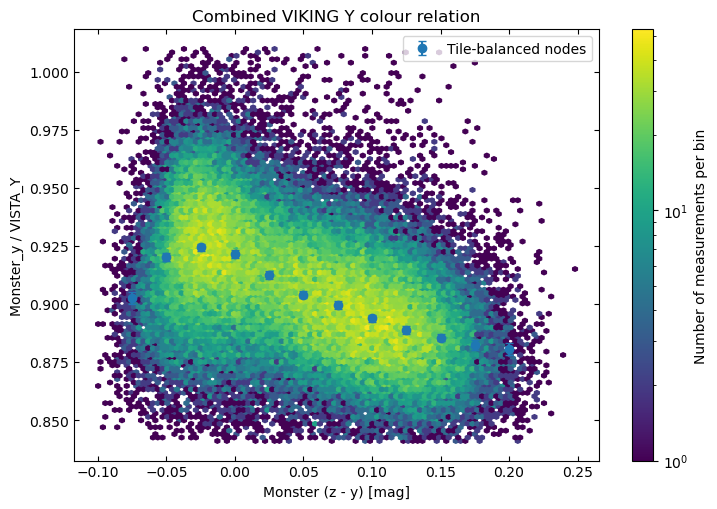


Saved:
  data/outputs/Monster_VIKING_Y/viking_y_tile_balanced_diagnostic_relation.pdf
  data/outputs/Monster_VIKING_Y/viking_y_tile_balanced_diagnostic_nodes.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table
from IPython.display import display


# -------------------------------------------------------------------
# Reload the combined samples when required
# -------------------------------------------------------------------

if "all_y_calibration_observations" not in globals():
    all_y_calibration_observations = Table.read(
        Y_OUTPUT_DIR
        / "viking_y_calibration_observations_all_tiles.fits"
    )

if "unique_y_calibration_sample" not in globals():
    unique_y_calibration_sample = Table.read(
        Y_OUTPUT_DIR
        / "viking_y_calibration_unique_sources.fits"
    )


# -------------------------------------------------------------------
# Diagnostic configuration
# -------------------------------------------------------------------

Y_DIAGNOSTIC_NODES = np.arange(
    -0.10,
    0.2501,
    0.025,
)

MINIMUM_STARS_PER_TILE_BIN = 10
MINIMUM_TILES_PER_NODE = 10

STAR_CLIP_THRESHOLD = 4.0
TILE_CLIP_THRESHOLD = 4.0
MAXIMUM_CLIP_ITERATIONS = 10


# -------------------------------------------------------------------
# Local helper functions
# -------------------------------------------------------------------

def y_diagnostic_float_array(column):
    """Convert an ordinary or masked column to float."""
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column,
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


def y_diagnostic_nmad(values):
    """Return 1.4826 times the median absolute deviation."""
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return np.nan

    centre = np.median(
        values
    )

    return float(
        1.4826
        * np.median(
            np.abs(
                values - centre
            )
        )
    )


def y_diagnostic_clip_mask(
    values,
    threshold,
):
    """Return the values retained by iterative median/NMAD clipping."""
    values = np.asarray(
        values,
        dtype=float,
    )

    keep = np.isfinite(
        values
    )

    for _ in range(
        MAXIMUM_CLIP_ITERATIONS
    ):
        retained = values[
            keep
        ]

        if len(retained) < 3:
            break

        centre = np.median(
            retained
        )

        scatter = y_diagnostic_nmad(
            retained
        )

        if (
            not np.isfinite(scatter)
            or scatter <= 0.0
        ):
            break

        new_keep = (
            np.isfinite(values)
            & (
                np.abs(
                    values - centre
                )
                <= threshold * scatter
            )
        )

        if np.array_equal(
            new_keep,
            keep,
        ):
            break

        keep = new_keep

    return keep


# -------------------------------------------------------------------
# Read the combined observations
# -------------------------------------------------------------------

combined_colour = y_diagnostic_float_array(
    all_y_calibration_observations[
        "monster_zy_colour"
    ]
)

combined_ratio = y_diagnostic_float_array(
    all_y_calibration_observations[
        "monster_y_over_vista_y"
    ]
)

combined_tile = np.asarray(
    all_y_calibration_observations[
        "viking_file"
    ]
).astype(str)


valid_combined = (
    np.isfinite(combined_colour)
    & np.isfinite(combined_ratio)
    & (combined_ratio > 0.0)
)

combined_colour = combined_colour[
    valid_combined
]

combined_ratio = combined_ratio[
    valid_combined
]

combined_tile = combined_tile[
    valid_combined
]


unique_colour = y_diagnostic_float_array(
    unique_y_calibration_sample[
        "monster_zy_colour"
    ]
)

unique_colour = unique_colour[
    np.isfinite(unique_colour)
]


# -------------------------------------------------------------------
# Print the combined colour distribution
# -------------------------------------------------------------------

colour_percentiles = [
    0.1,
    0.5,
    1.0,
    5.0,
    50.0,
    95.0,
    99.0,
    99.5,
    99.9,
]

colour_percentile_values = np.percentile(
    unique_colour,
    colour_percentiles,
)


print("=" * 72)
print("COMBINED Y-BAND COLOUR DISTRIBUTION")
print("=" * 72)

print(
    f"Tile measurements          : "
    f"{len(combined_colour):,}"
)

print(
    f"Unique Monster sources     : "
    f"{len(unique_colour):,}"
)

print(
    f"Number of VIKING tiles     : "
    f"{len(np.unique(combined_tile))}"
)


colour_percentile_table = pd.DataFrame(
    {
        "percentile":
            colour_percentiles,

        "monster_z_minus_y":
            colour_percentile_values,
    }
)

display(
    colour_percentile_table
)


# -------------------------------------------------------------------
# Construct colour bins centred on the candidate nodes
# -------------------------------------------------------------------

node_midpoints = 0.5 * (
    Y_DIAGNOSTIC_NODES[:-1]
    + Y_DIAGNOSTIC_NODES[1:]
)

node_edges = np.concatenate(
    [
        [
            Y_DIAGNOSTIC_NODES[0]
            - (
                node_midpoints[0]
                - Y_DIAGNOSTIC_NODES[0]
            )
        ],
        node_midpoints,
        [
            Y_DIAGNOSTIC_NODES[-1]
            + (
                Y_DIAGNOSTIC_NODES[-1]
                - node_midpoints[-1]
            )
        ],
    ]
)


# -------------------------------------------------------------------
# Calculate tile-balanced diagnostic nodes
# -------------------------------------------------------------------

node_records = []


for node_index, node_colour in enumerate(
    Y_DIAGNOSTIC_NODES
):
    in_colour_bin = (
        combined_colour
        >= node_edges[node_index]
    ) & (
        combined_colour
        < node_edges[node_index + 1]
    )

    if node_index == len(
        Y_DIAGNOSTIC_NODES
    ) - 1:
        in_colour_bin = (
            combined_colour
            >= node_edges[node_index]
        ) & (
            combined_colour
            <= node_edges[node_index + 1]
        )


    tile_medians = []

    for tile_name in np.unique(
        combined_tile[
            in_colour_bin
        ]
    ):
        tile_selection = (
            in_colour_bin
            & (
                combined_tile
                == tile_name
            )
        )

        tile_values = combined_ratio[
            tile_selection
        ]

        if (
            len(tile_values)
            < MINIMUM_STARS_PER_TILE_BIN
        ):
            continue

        star_keep = y_diagnostic_clip_mask(
            tile_values,
            STAR_CLIP_THRESHOLD,
        )

        retained_values = tile_values[
            star_keep
        ]

        if (
            len(retained_values)
            < MINIMUM_STARS_PER_TILE_BIN
        ):
            continue

        tile_medians.append(
            float(
                np.median(
                    retained_values
                )
            )
        )


    tile_medians = np.asarray(
        tile_medians,
        dtype=float,
    )

    number_of_tiles_before = len(
        tile_medians
    )


    if (
        number_of_tiles_before
        >= MINIMUM_TILES_PER_NODE
    ):
        tile_keep = y_diagnostic_clip_mask(
            tile_medians,
            TILE_CLIP_THRESHOLD,
        )

        retained_tile_medians = (
            tile_medians[
                tile_keep
            ]
        )
    else:
        retained_tile_medians = np.array(
            [],
            dtype=float,
        )


    number_of_tiles_after = len(
        retained_tile_medians
    )


    if (
        number_of_tiles_after
        >= MINIMUM_TILES_PER_NODE
    ):
        node_ratio = float(
            np.median(
                retained_tile_medians
            )
        )

        tile_nmad = y_diagnostic_nmad(
            retained_tile_medians
        )

        node_uncertainty = (
            1.2533
            * tile_nmad
            / np.sqrt(
                number_of_tiles_after
            )
        )
    else:
        node_ratio = np.nan
        tile_nmad = np.nan
        node_uncertainty = np.nan


    star_weighted_median = (
        float(
            np.median(
                combined_ratio[
                    in_colour_bin
                ]
            )
        )
        if np.any(
            in_colour_bin
        )
        else np.nan
    )


    node_records.append(
        {
            "node_colour":
                float(node_colour),

            "bin_lower_edge":
                float(node_edges[node_index]),

            "bin_upper_edge":
                float(node_edges[node_index + 1]),

            "number_of_stars":
                int(
                    np.count_nonzero(
                        in_colour_bin
                    )
                ),

            "number_of_tiles_before_clipping":
                int(
                    number_of_tiles_before
                ),

            "number_of_tiles_after_clipping":
                int(
                    number_of_tiles_after
                ),

            "tile_balanced_ratio":
                node_ratio,

            "star_weighted_ratio":
                star_weighted_median,

            "tile_median_nmad":
                tile_nmad,

            "node_uncertainty":
                node_uncertainty,
        }
    )


y_diagnostic_node_table = pd.DataFrame(
    node_records
)


print("\n" + "=" * 72)
print("Y-BAND TILE-BALANCED DIAGNOSTIC NODES")
print("=" * 72)

display(
    y_diagnostic_node_table
)


# -------------------------------------------------------------------
# Summarise nodes with broad survey support
# -------------------------------------------------------------------

number_of_tiles = len(
    np.unique(
        combined_tile
    )
)

broad_support_limit = int(
    np.ceil(
        0.60
        * number_of_tiles
    )
)

broadly_supported_nodes = (
    y_diagnostic_node_table[
        y_diagnostic_node_table[
            "number_of_tiles_after_clipping"
        ]
        >= broad_support_limit
    ]
)


print(
    f"\nBroad-support requirement: "
    f"at least {broad_support_limit} of "
    f"{number_of_tiles} tiles"
)


if len(
    broadly_supported_nodes
) > 0:
    print(
        "Broadly supported node range: "
        f"{broadly_supported_nodes['node_colour'].min():.3f} "
        "to "
        f"{broadly_supported_nodes['node_colour'].max():.3f}"
    )
else:
    print(
        "No nodes meet the broad-support requirement."
    )


# -------------------------------------------------------------------
# Plot the combined relation and diagnostic nodes
# -------------------------------------------------------------------

plot_colour_min = float(
    Y_DIAGNOSTIC_NODES[0]
)

plot_colour_max = float(
    Y_DIAGNOSTIC_NODES[-1]
)

ratio_display_low = float(
    np.percentile(
        combined_ratio,
        0.5,
    )
)

ratio_display_high = float(
    np.percentile(
        combined_ratio,
        99.5,
    )
)


plot_mask = (
    (combined_colour >= plot_colour_min)
    & (combined_colour <= plot_colour_max)
    & (combined_ratio >= ratio_display_low)
    & (combined_ratio <= ratio_display_high)
)


valid_nodes = np.isfinite(
    y_diagnostic_node_table[
        "tile_balanced_ratio"
    ]
)


figure, axis = plt.subplots(
    figsize=(7.5, 5.2),
)

density = axis.hexbin(
    combined_colour[
        plot_mask
    ],
    combined_ratio[
        plot_mask
    ],
    gridsize=100,
    mincnt=1,
    bins="log",
)

axis.errorbar(
    y_diagnostic_node_table.loc[
        valid_nodes,
        "node_colour",
    ],
    y_diagnostic_node_table.loc[
        valid_nodes,
        "tile_balanced_ratio",
    ],
    yerr=y_diagnostic_node_table.loc[
        valid_nodes,
        "node_uncertainty",
    ],
    fmt="o",
    capsize=3,
    label="Tile-balanced nodes",
)

axis.set_xlabel(
    "Monster (z - y) [mag]"
)

axis.set_ylabel(
    "Monster_y / VISTA_Y"
)

axis.set_title(
    "Combined VIKING Y colour relation"
)

axis.legend()

axis.tick_params(
    direction="in",
    top=True,
    right=True,
)

colourbar = figure.colorbar(
    density,
    ax=axis,
)

colourbar.set_label(
    "Number of measurements per bin"
)

figure.tight_layout()


diagnostic_plot_path = (
    Y_OUTPUT_DIR
    / "viking_y_tile_balanced_diagnostic_relation.pdf"
)

figure.savefig(
    diagnostic_plot_path,
    bbox_inches="tight",
)

plt.show()


# -------------------------------------------------------------------
# Save the diagnostic table
# -------------------------------------------------------------------

diagnostic_table_path = (
    Y_OUTPUT_DIR
    / "viking_y_tile_balanced_diagnostic_nodes.csv"
)

y_diagnostic_node_table.to_csv(
    diagnostic_table_path,
    index=False,
)


print("\nSaved:")
print(f"  {diagnostic_plot_path}")
print(f"  {diagnostic_table_path}")

### Result

The combined sample supports a final colour range from Monster z - y = -0.075
to 0.175. The central nodes are measured from more than 80 tiles, while the
two endpoints remain supported by 54 and 52 tiles.

The relation rises from a ratio of approximately 0.903 at the blue endpoint
to a maximum of 0.924 near z - y = -0.025, then decreases smoothly to 0.882
at the red endpoint. Tile-balanced and star-weighted node values differ by
less than 0.0015 over the adopted range.

The node at z - y = 0.20 is supported by only 28 tiles, so it is not included
in the final survey-wide transformation.

## 6. Derive and validate the final Y-band spline

The final colour range is:

    -0.075 <= Monster z - y <= 0.175

Complete VIKING tiles are divided into fitting and validation groups within
each survey region. Every fifth tile is withheld for validation. Monster
sources present in a validation tile are removed from the fitting sample,
including repeated measurements in overlapping tiles.

Robust tile-balanced node values are first derived from the fitting tiles.
The resulting spline is tested on the withheld tiles. The final node values
are then recalculated using all 87 catalogues.

This cell saves the final node table and independent validation results. The
YAML file will be written after inspecting these results.

FINAL Y-BAND TILE SPLIT
Total tiles             : 87
Fitting tiles           : 69
Validation tiles        : 18
Fitting observations    : 57,714
Validation observations : 16,198


,region,subset,number_of_tiles
0,northern_equatorial,fitting,36
1,northern_equatorial,validation,9
2,southern,fitting,33
3,southern,validation,9



Validation-fit nodes
--------------------


,node_colour,bin_lower_edge,bin_upper_edge,number_of_stars,number_of_tiles_before_clipping,number_of_tiles_after_clipping,node_ratio,tile_median_nmad,node_uncertainty
0,-7.500000e-02,-0.0875,-0.0625,739,39,39,0.904350,0.015088,0.003028
1,-5.000000e-02,-0.0625,-0.0375,4265,68,68,0.920057,0.012296,0.001869
2,-2.500000e-02,-0.0375,-0.0125,8122,69,69,0.923796,0.012015,0.001813
3,1.387779e-17,-0.0125,0.0125,7321,69,69,0.921884,0.013189,0.001990
4,2.500000e-02,0.0125,0.0375,5779,68,68,0.912837,0.011262,0.001712
5,5.000000e-02,0.0375,0.0625,6034,67,67,0.903613,0.012044,0.001844
6,7.500000e-02,0.0625,0.0875,6751,67,67,0.899604,0.013803,0.002113
7,1.000000e-01,0.0875,0.1125,6939,66,66,0.894029,0.010953,0.001690
8,1.250000e-01,0.1125,0.1375,5969,65,65,0.887517,0.012238,0.001902
9,1.500000e-01,0.1375,0.1625,3775,65,65,0.885684,0.011247,0.001748



INDEPENDENT Y-BAND VALIDATION
Unique validation sources       : 15,849
Median residual                 : +0.001781
Residual NMAD                   : 0.021074
Fractional residual NMAD        : 2.329 per cent
Residual-colour Spearman rho    : -0.0055
Residual-colour p-value         : 4.888e-01
Residual-magnitude Spearman rho : +0.2708
Residual-magnitude p-value      : 2.374e-264

Regional validation
-------------------


...


Final all-tile nodes
--------------------


,node_colour,bin_lower_edge,bin_upper_edge,number_of_stars,number_of_tiles_before_clipping,number_of_tiles_after_clipping,node_ratio,tile_median_nmad,node_uncertainty
0,-7.500000e-02,-0.0875,-0.0625,722,31,31,0.906485,0.013446,0.003027
1,-5.000000e-02,-0.0625,-0.0375,5516,86,86,0.920057,0.012710,0.001718
2,-2.500000e-02,-0.0375,-0.0125,10440,87,87,0.924296,0.012757,0.001714
3,1.387779e-17,-0.0125,0.0125,9201,87,87,0.921603,0.012548,0.001686
4,2.500000e-02,0.0125,0.0375,7355,86,86,0.912544,0.013220,0.001787
5,5.000000e-02,0.0375,0.0625,7814,83,83,0.904041,0.011495,0.001581
6,7.500000e-02,0.0625,0.0875,8755,84,84,0.899540,0.013512,0.001848
7,1.000000e-01,0.0875,0.1125,9059,83,83,0.893744,0.011250,0.001548
8,1.250000e-01,0.1125,0.1375,7766,82,82,0.888659,0.012033,0.001665
9,1.500000e-01,0.1375,0.1625,4856,82,82,0.885532,0.009636,0.001334



Final versus validation-fit nodes
---------------------------------


,node_colour,validation_fit_ratio,final_all_tile_ratio,final_minus_validation
0,-7.500000e-02,0.904350,0.906485,0.002135
1,-5.000000e-02,0.920057,0.920057,0.000000
2,-2.500000e-02,0.923796,0.924296,0.000500
3,1.387779e-17,0.921884,0.921603,-0.000281
4,2.500000e-02,0.912837,0.912544,-0.000293
5,5.000000e-02,0.903613,0.904041,0.000428
6,7.500000e-02,0.899604,0.899540,-0.000064
7,1.000000e-01,0.894029,0.893744,-0.000285
8,1.250000e-01,0.887517,0.888659,0.001142
9,1.500000e-01,0.885684,0.885532,-0.000152



Maximum absolute node difference: 0.002135


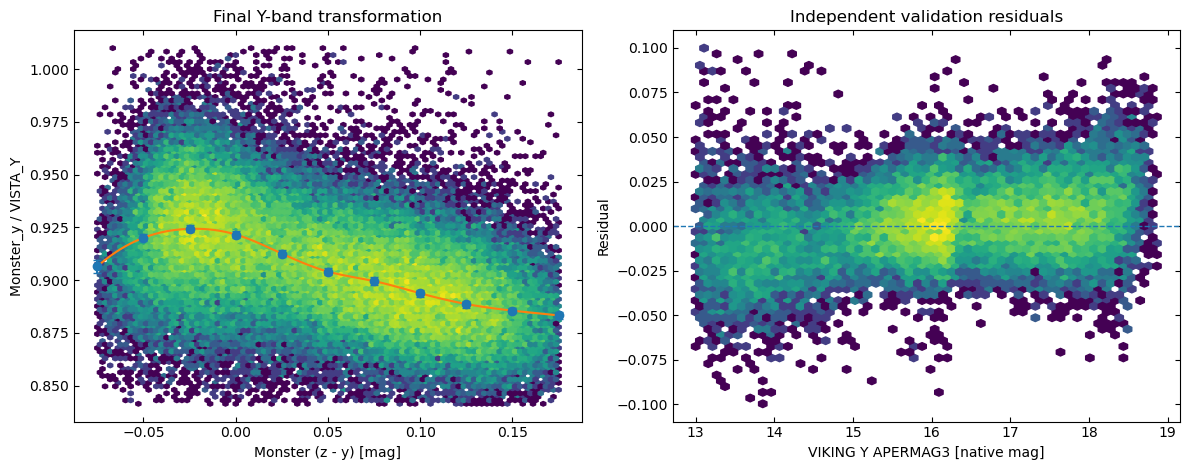


Saved: data/outputs/Monster_VIKING_Y/viking_y_final_validation.pdf

Saved:
  data/outputs/Monster_VIKING_Y/viking_y_validation_fit_nodes.csv
  data/outputs/Monster_VIKING_Y/viking_y_final_nodes.csv
  data/outputs/Monster_VIKING_Y/viking_y_final_vs_validation_nodes.csv
  data/outputs/Monster_VIKING_Y/viking_y_regional_validation_summary.csv
  data/outputs/Monster_VIKING_Y/viking_y_validation_residuals.csv


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table
from scipy.interpolate import make_interp_spline
from scipy.stats import spearmanr
from IPython.display import display


# -------------------------------------------------------------------
# Final configuration
# -------------------------------------------------------------------

FINAL_Y_NODES = np.arange(
    -0.075,
    0.1751,
    0.025,
)

VALIDATION_TILE_INTERVAL = 5

MINIMUM_STARS_PER_TILE_BIN = 10
MINIMUM_TILES_PER_NODE = 10

STAR_CLIP_THRESHOLD = 4.0
TILE_CLIP_THRESHOLD = 4.0
MAXIMUM_CLIP_ITERATIONS = 10


# -------------------------------------------------------------------
# Reload the combined sample if needed
# -------------------------------------------------------------------

if "all_y_calibration_observations" not in globals():
    all_y_calibration_observations = Table.read(
        Y_OUTPUT_DIR
        / "viking_y_calibration_observations_all_tiles.fits"
    )


# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------

def final_y_float_array(column):
    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                column,
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


def final_y_nmad(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return np.nan

    centre = np.median(
        values
    )

    return float(
        1.4826
        * np.median(
            np.abs(
                values - centre
            )
        )
    )


def final_y_clip_mask(
    values,
    threshold,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    keep = np.isfinite(
        values
    )

    for _ in range(
        MAXIMUM_CLIP_ITERATIONS
    ):
        retained = values[
            keep
        ]

        if len(retained) < 3:
            break

        centre = np.median(
            retained
        )

        scatter = final_y_nmad(
            retained
        )

        if (
            not np.isfinite(scatter)
            or scatter <= 0.0
        ):
            break

        new_keep = (
            np.isfinite(values)
            & (
                np.abs(
                    values - centre
                )
                <= threshold * scatter
            )
        )

        if np.array_equal(
            new_keep,
            keep,
        ):
            break

        keep = new_keep

    return keep


def final_y_node_edges(nodes):
    midpoints = 0.5 * (
        nodes[:-1]
        + nodes[1:]
    )

    return np.concatenate(
        [
            [
                nodes[0]
                - (
                    midpoints[0]
                    - nodes[0]
                )
            ],
            midpoints,
            [
                nodes[-1]
                + (
                    nodes[-1]
                    - midpoints[-1]
                )
            ],
        ]
    )


def build_y_tile_balanced_nodes(
    colours,
    ratios,
    tile_names,
    selection,
    nodes,
):
    edges = final_y_node_edges(
        nodes
    )

    records = []

    for node_index, node_colour in enumerate(
        nodes
    ):
        in_bin = (
            selection
            & (
                colours
                >= edges[node_index]
            )
            & (
                colours
                < edges[node_index + 1]
            )
        )

        if node_index == len(nodes) - 1:
            in_bin = (
                selection
                & (
                    colours
                    >= edges[node_index]
                )
                & (
                    colours
                    <= edges[node_index + 1]
                )
            )

        tile_medians = []

        for tile_name in np.unique(
            tile_names[
                in_bin
            ]
        ):
            tile_selection = (
                in_bin
                & (
                    tile_names
                    == tile_name
                )
            )

            tile_values = ratios[
                tile_selection
            ]

            if (
                len(tile_values)
                < MINIMUM_STARS_PER_TILE_BIN
            ):
                continue

            star_keep = final_y_clip_mask(
                tile_values,
                STAR_CLIP_THRESHOLD,
            )

            retained_values = tile_values[
                star_keep
            ]

            if (
                len(retained_values)
                < MINIMUM_STARS_PER_TILE_BIN
            ):
                continue

            tile_medians.append(
                float(
                    np.median(
                        retained_values
                    )
                )
            )

        tile_medians = np.asarray(
            tile_medians,
            dtype=float,
        )

        number_before = len(
            tile_medians
        )

        if (
            number_before
            >= MINIMUM_TILES_PER_NODE
        ):
            tile_keep = final_y_clip_mask(
                tile_medians,
                TILE_CLIP_THRESHOLD,
            )

            retained_tile_medians = (
                tile_medians[
                    tile_keep
                ]
            )
        else:
            retained_tile_medians = np.array(
                [],
                dtype=float,
            )

        number_after = len(
            retained_tile_medians
        )

        if (
            number_after
            < MINIMUM_TILES_PER_NODE
        ):
            node_ratio = np.nan
            tile_nmad = np.nan
            node_uncertainty = np.nan

        else:
            node_ratio = float(
                np.median(
                    retained_tile_medians
                )
            )

            tile_nmad = final_y_nmad(
                retained_tile_medians
            )

            node_uncertainty = (
                1.2533
                * tile_nmad
                / np.sqrt(
                    number_after
                )
            )

        records.append(
            {
                "node_colour":
                    float(node_colour),

                "bin_lower_edge":
                    float(edges[node_index]),

                "bin_upper_edge":
                    float(edges[node_index + 1]),

                "number_of_stars":
                    int(
                        np.count_nonzero(
                            in_bin
                        )
                    ),

                "number_of_tiles_before_clipping":
                    int(number_before),

                "number_of_tiles_after_clipping":
                    int(number_after),

                "node_ratio":
                    node_ratio,

                "tile_median_nmad":
                    tile_nmad,

                "node_uncertainty":
                    node_uncertainty,
            }
        )

    result = pd.DataFrame(
        records
    )

    unsupported = (
        ~np.isfinite(
            result["node_ratio"]
        )
    )

    if np.any(unsupported):
        raise RuntimeError(
            "Insufficient support for final nodes:\n"
            f"{result.loc[unsupported]}"
        )

    return result


def evaluate_y_spline(
    spline,
    colours,
):
    model = np.full(
        len(colours),
        np.nan,
        dtype=float,
    )

    valid = (
        np.isfinite(colours)
        & (
            colours
            >= FINAL_Y_NODES[0]
        )
        & (
            colours
            <= FINAL_Y_NODES[-1]
        )
    )

    model[valid] = spline(
        colours[valid]
    )

    return model


# -------------------------------------------------------------------
# Observation arrays
# -------------------------------------------------------------------

monster_id = np.asarray(
    all_y_calibration_observations[
        "monster_id"
    ],
    dtype=np.int64,
)

tile_name = np.asarray(
    all_y_calibration_observations[
        "viking_file"
    ]
).astype(str)

region = np.asarray(
    all_y_calibration_observations[
        "region"
    ]
).astype(str)

colour = final_y_float_array(
    all_y_calibration_observations[
        "monster_zy_colour"
    ]
)

measured_ratio = final_y_float_array(
    all_y_calibration_observations[
        "monster_y_over_vista_y"
    ]
)

native_y_magnitude = final_y_float_array(
    all_y_calibration_observations[
        "viking_y_mag_native"
    ]
)

viking_y_snr = final_y_float_array(
    all_y_calibration_observations[
        "viking_y_snr"
    ]
)

separation = final_y_float_array(
    all_y_calibration_observations[
        "separation_arcsec"
    ]
)


valid_input = (
    np.isfinite(colour)
    & np.isfinite(measured_ratio)
    & (measured_ratio > 0.0)
    & np.isfinite(native_y_magnitude)
)


# -------------------------------------------------------------------
# Select fitting and validation tiles
# -------------------------------------------------------------------

tile_region_table = (
    pd.DataFrame(
        {
            "viking_file":
                tile_name,

            "region":
                region,
        }
    )
    .drop_duplicates(
        subset="viking_file"
    )
    .sort_values(
        [
            "region",
            "viking_file",
        ]
    )
    .reset_index(
        drop=True
    )
)


validation_tiles = []

for region_name in sorted(
    tile_region_table[
        "region"
    ].unique()
):
    regional_tiles = (
        tile_region_table[
            tile_region_table[
                "region"
            ]
            == region_name
        ][
            "viking_file"
        ]
        .sort_values()
        .to_numpy()
    )

    validation_tiles.extend(
        regional_tiles[
            ::VALIDATION_TILE_INTERVAL
        ]
    )


validation_tiles = np.asarray(
    validation_tiles,
    dtype=str,
)

fitting_tiles = tile_region_table[
    ~tile_region_table[
        "viking_file"
    ].isin(
        validation_tiles
    )
][
    "viking_file"
].to_numpy()


validation_observation_mask = (
    valid_input
    & np.isin(
        tile_name,
        validation_tiles,
    )
)

validation_monster_ids = np.unique(
    monster_id[
        validation_observation_mask
    ]
)

fitting_observation_mask = (
    valid_input
    & np.isin(
        tile_name,
        fitting_tiles,
    )
    & ~np.isin(
        monster_id,
        validation_monster_ids,
    )
)


print("=" * 72)
print("FINAL Y-BAND TILE SPLIT")
print("=" * 72)

print(
    f"Total tiles             : "
    f"{len(tile_region_table)}"
)

print(
    f"Fitting tiles           : "
    f"{len(fitting_tiles)}"
)

print(
    f"Validation tiles        : "
    f"{len(validation_tiles)}"
)

print(
    f"Fitting observations    : "
    f"{np.count_nonzero(fitting_observation_mask):,}"
)

print(
    f"Validation observations : "
    f"{np.count_nonzero(validation_observation_mask):,}"
)


split_summary = (
    tile_region_table
    .assign(
        subset=np.where(
            tile_region_table[
                "viking_file"
            ].isin(
                validation_tiles
            ),
            "validation",
            "fitting",
        )
    )
    .groupby(
        [
            "region",
            "subset",
        ]
    )
    .size()
    .reset_index(
        name="number_of_tiles"
    )
)

display(
    split_summary
)


# -------------------------------------------------------------------
# Fit using fitting tiles
# -------------------------------------------------------------------

validation_fit_nodes = build_y_tile_balanced_nodes(
    colours=colour,
    ratios=measured_ratio,
    tile_names=tile_name,
    selection=fitting_observation_mask,
    nodes=FINAL_Y_NODES,
)

validation_y_spline = make_interp_spline(
    validation_fit_nodes[
        "node_colour"
    ].to_numpy(dtype=float),

    validation_fit_nodes[
        "node_ratio"
    ].to_numpy(dtype=float),

    k=3,
)


print("\nValidation-fit nodes")
print("--------------------")

display(
    validation_fit_nodes
)


# -------------------------------------------------------------------
# Select one observation per validation source
# -------------------------------------------------------------------

validation_indices = np.flatnonzero(
    validation_observation_mask
)

validation_order = np.lexsort(
    (
        separation[
            validation_indices
        ],
        -viking_y_snr[
            validation_indices
        ],
        monster_id[
            validation_indices
        ],
    )
)

ordered_validation_indices = (
    validation_indices[
        validation_order
    ]
)

ordered_validation_ids = monster_id[
    ordered_validation_indices
]

_, first_validation_rows = np.unique(
    ordered_validation_ids,
    return_index=True,
)

unique_validation_indices = (
    ordered_validation_indices[
        first_validation_rows
    ]
)


validation_id = monster_id[
    unique_validation_indices
]

validation_colour = colour[
    unique_validation_indices
]

validation_ratio = measured_ratio[
    unique_validation_indices
]

validation_magnitude = native_y_magnitude[
    unique_validation_indices
]

validation_region = region[
    unique_validation_indices
]


validation_model = evaluate_y_spline(
    validation_y_spline,
    validation_colour,
)

validation_residual = (
    validation_ratio
    - validation_model
)

valid_validation = (
    np.isfinite(validation_residual)
    & np.isfinite(validation_model)
    & (validation_model > 0.0)
)

fractional_residual = (
    validation_residual[
        valid_validation
    ]
    / validation_model[
        valid_validation
    ]
)


colour_test = spearmanr(
    validation_colour[
        valid_validation
    ],
    validation_residual[
        valid_validation
    ],
)

magnitude_test = spearmanr(
    validation_magnitude[
        valid_validation
    ],
    validation_residual[
        valid_validation
    ],
)


print("\n" + "=" * 72)
print("INDEPENDENT Y-BAND VALIDATION")
print("=" * 72)

print(
    f"Unique validation sources       : "
    f"{np.count_nonzero(valid_validation):,}"
)

print(
    f"Median residual                 : "
    f"{np.median(validation_residual[valid_validation]):+.6f}"
)

print(
    f"Residual NMAD                   : "
    f"{final_y_nmad(validation_residual[valid_validation]):.6f}"
)

print(
    f"Fractional residual NMAD        : "
    f"{100.0 * final_y_nmad(fractional_residual):.3f} per cent"
)

print(
    f"Residual-colour Spearman rho    : "
    f"{colour_test.statistic:+.4f}"
)

print(
    f"Residual-colour p-value         : "
    f"{colour_test.pvalue:.3e}"
)

print(
    f"Residual-magnitude Spearman rho : "
    f"{magnitude_test.statistic:+.4f}"
)

print(
    f"Residual-magnitude p-value      : "
    f"{magnitude_test.pvalue:.3e}"
)


# -------------------------------------------------------------------
# Regional validation summary
# -------------------------------------------------------------------

regional_records = []

for region_name in sorted(
    np.unique(
        validation_region[
            valid_validation
        ]
    )
):
    regional_mask = (
        valid_validation
        & (
            validation_region
            == region_name
        )
    )

    regional_residual = validation_residual[
        regional_mask
    ]

    regional_model = validation_model[
        regional_mask
    ]

    regional_records.append(
        {
            "region":
                region_name,

            "number_of_sources":
                int(
                    np.count_nonzero(
                        regional_mask
                    )
                ),

            "median_residual":
                float(
                    np.median(
                        regional_residual
                    )
                ),

            "residual_nmad":
                final_y_nmad(
                    regional_residual
                ),

            "fractional_nmad_percent":
                100.0
                * final_y_nmad(
                    regional_residual
                    / regional_model
                ),
        }
    )


regional_validation_summary = pd.DataFrame(
    regional_records
)

print("\nRegional validation")
print("-------------------")

display(
    regional_validation_summary
)


# -------------------------------------------------------------------
# Refit using all 87 tiles
# -------------------------------------------------------------------

all_tile_selection = (
    valid_input
    & (
        colour
        >= FINAL_Y_NODES[0]
    )
    & (
        colour
        <= FINAL_Y_NODES[-1]
    )
)

final_y_node_table = build_y_tile_balanced_nodes(
    colours=colour,
    ratios=measured_ratio,
    tile_names=tile_name,
    selection=all_tile_selection,
    nodes=FINAL_Y_NODES,
)

final_y_spline = make_interp_spline(
    final_y_node_table[
        "node_colour"
    ].to_numpy(dtype=float),

    final_y_node_table[
        "node_ratio"
    ].to_numpy(dtype=float),

    k=3,
)


node_comparison = pd.DataFrame(
    {
        "node_colour":
            FINAL_Y_NODES,

        "validation_fit_ratio":
            validation_fit_nodes[
                "node_ratio"
            ].to_numpy(dtype=float),

        "final_all_tile_ratio":
            final_y_node_table[
                "node_ratio"
            ].to_numpy(dtype=float),
    }
)

node_comparison[
    "final_minus_validation"
] = (
    node_comparison[
        "final_all_tile_ratio"
    ]
    - node_comparison[
        "validation_fit_ratio"
    ]
)


print("\nFinal all-tile nodes")
print("--------------------")

display(
    final_y_node_table
)

print("\nFinal versus validation-fit nodes")
print("---------------------------------")

display(
    node_comparison
)

print(
    f"\nMaximum absolute node difference: "
    f"{np.max(np.abs(node_comparison['final_minus_validation'])):.6f}"
)


# -------------------------------------------------------------------
# Diagnostic figure
# -------------------------------------------------------------------

smooth_colour = np.linspace(
    FINAL_Y_NODES[0],
    FINAL_Y_NODES[-1],
    600,
)

smooth_final_ratio = final_y_spline(
    smooth_colour
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
)


plot_mask = (
    all_tile_selection
    & (
        measured_ratio
        >= np.percentile(
            measured_ratio[
                all_tile_selection
            ],
            0.5,
        )
    )
    & (
        measured_ratio
        <= np.percentile(
            measured_ratio[
                all_tile_selection
            ],
            99.5,
        )
    )
)


axes[0].hexbin(
    colour[
        plot_mask
    ],
    measured_ratio[
        plot_mask
    ],
    gridsize=90,
    mincnt=1,
    bins="log",
)

axes[0].errorbar(
    final_y_node_table[
        "node_colour"
    ],
    final_y_node_table[
        "node_ratio"
    ],
    yerr=final_y_node_table[
        "node_uncertainty"
    ],
    fmt="o",
    capsize=3,
)

axes[0].plot(
    smooth_colour,
    smooth_final_ratio,
    linewidth=1.5,
)

axes[0].set_xlabel(
    "Monster (z - y) [mag]"
)

axes[0].set_ylabel(
    "Monster_y / VISTA_Y"
)

axes[0].set_title(
    "Final Y-band transformation"
)


residual_plot_mask = (
    valid_validation
    & (
        validation_residual
        >= -0.10
    )
    & (
        validation_residual
        <= 0.10
    )
)

axes[1].hexbin(
    validation_magnitude[
        residual_plot_mask
    ],
    validation_residual[
        residual_plot_mask
    ],
    gridsize=55,
    mincnt=1,
    bins="log",
)

axes[1].axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

axes[1].set_xlabel(
    "VIKING Y APERMAG3 [native mag]"
)

axes[1].set_ylabel(
    "Residual"
)

axes[1].set_title(
    "Independent validation residuals"
)


for axis in axes:
    axis.tick_params(
        direction="in",
        top=True,
        right=True,
    )


figure.tight_layout()

validation_plot_path = (
    Y_OUTPUT_DIR
    / "viking_y_final_validation.pdf"
)

figure.savefig(
    validation_plot_path,
    bbox_inches="tight",
)

plt.show()

print(
    f"\nSaved: {validation_plot_path}"
)


# -------------------------------------------------------------------
# Save tables
# -------------------------------------------------------------------

validation_nodes_path = (
    Y_OUTPUT_DIR
    / "viking_y_validation_fit_nodes.csv"
)

final_nodes_path = (
    Y_OUTPUT_DIR
    / "viking_y_final_nodes.csv"
)

node_comparison_path = (
    Y_OUTPUT_DIR
    / "viking_y_final_vs_validation_nodes.csv"
)

regional_summary_path = (
    Y_OUTPUT_DIR
    / "viking_y_regional_validation_summary.csv"
)

validation_residuals_path = (
    Y_OUTPUT_DIR
    / "viking_y_validation_residuals.csv"
)


validation_fit_nodes.to_csv(
    validation_nodes_path,
    index=False,
)

final_y_node_table.to_csv(
    final_nodes_path,
    index=False,
)

node_comparison.to_csv(
    node_comparison_path,
    index=False,
)

regional_validation_summary.to_csv(
    regional_summary_path,
    index=False,
)


validation_residual_table = pd.DataFrame(
    {
        "monster_id":
            validation_id,

        "region":
            validation_region,

        "monster_zy_colour":
            validation_colour,

        "viking_y_mag_native":
            validation_magnitude,

        "measured_ratio":
            validation_ratio,

        "model_ratio":
            validation_model,

        "ratio_residual":
            validation_residual,
    }
)

validation_residual_table.to_csv(
    validation_residuals_path,
    index=False,
)


print("\nSaved:")
print(f"  {validation_nodes_path}")
print(f"  {final_nodes_path}")
print(f"  {node_comparison_path}")
print(f"  {regional_summary_path}")
print(f"  {validation_residuals_path}")

### Result

The final Y-band spline is stable under independent tile validation. The
maximum difference between the validation-fit and all-tile node values is
0.00214, corresponding to approximately 0.24 per cent.

The northern/equatorial and southern validation samples have fractional
residual NMAD values of 2.10 and 2.46 per cent, respectively. Their median
residuals differ by approximately 0.004 in flux ratio, with no evidence for
a different colour-term shape between the two regions.

All 87 VIKING catalogues are therefore retained, and the final colour range
is adopted as:

    -0.075 <= Monster z - y <= 0.175

## 7. Write the final Y-band YAML and publication figure

The final tile-balanced node values are written in the standard Monster
colour-term YAML format.

The publication figure follows the same plotting format used for the Z-band
calibration. The left panel shows the complete calibration sample and final
spline. The right panel shows independent validation residuals against the
Monster y-band magnitude.

Only the displayed plotting ranges are restricted. These limits do not alter
the fitted sample, final spline, or validation statistics.

Final YAML written and verified:
Monster_to_VISTA_band_y.yaml


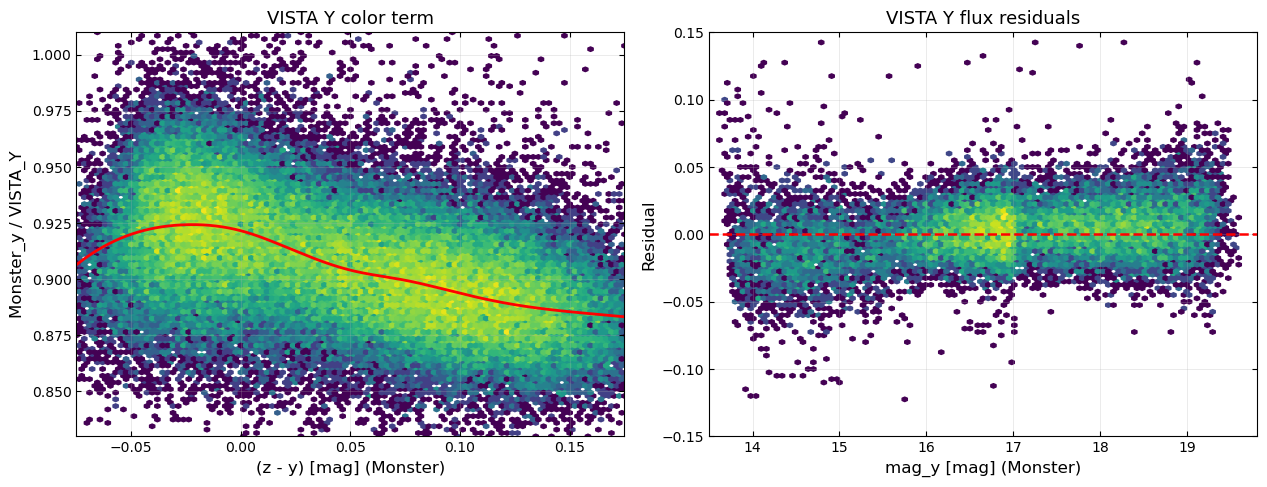


Saved publication figure:
  data/outputs/Monster_VIKING_Y/viking_y_calibration_publication.pdf
  data/outputs/Monster_VIKING_Y/viking_y_calibration_publication.png

Displayed samples:
  Colour-relation measurements : 72,243
  Validation residuals         : 15,784


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from astropy.table import Table
from scipy.interpolate import make_interp_spline


# -------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------

Y_OUTPUT_DIR = Path(
    "data/outputs/Monster_VIKING_Y"
)

OBSERVATION_PATH = (
    Y_OUTPUT_DIR
    / "viking_y_calibration_observations_all_tiles.fits"
)

FINAL_NODE_PATH = (
    Y_OUTPUT_DIR
    / "viking_y_final_nodes.csv"
)

VALIDATION_PATH = (
    Y_OUTPUT_DIR
    / "viking_y_validation_residuals.csv"
)

FINAL_YAML_PATH = (
    "Monster_to_VISTA_band_y.yaml"
)

PUBLICATION_PDF_PATH = (
    Y_OUTPUT_DIR
    / "viking_y_calibration_publication.pdf"
)

PUBLICATION_PNG_PATH = (
    Y_OUTPUT_DIR
    / "viking_y_calibration_publication.png"
)


for required_path in [
    OBSERVATION_PATH,
    FINAL_NODE_PATH,
    VALIDATION_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required final product was not found:\n"
            f"{required_path}"
        )


# -------------------------------------------------------------------
# Read final products
# -------------------------------------------------------------------

all_y_observations = Table.read(
    OBSERVATION_PATH
)

final_y_nodes_table = pd.read_csv(
    FINAL_NODE_PATH
)

y_validation_table = pd.read_csv(
    VALIDATION_PATH
)


final_nodes = final_y_nodes_table[
    "node_colour"
].to_numpy(dtype=float)

final_node_values = final_y_nodes_table[
    "node_ratio"
].to_numpy(dtype=float)


final_spline = make_interp_spline(
    final_nodes,
    final_node_values,
    k=3,
)

smooth_colour = np.linspace(
    final_nodes[0],
    final_nodes[-1],
    1000,
)

smooth_ratio = final_spline(
    smooth_colour
)


# -------------------------------------------------------------------
# Write the final Monster colour-term YAML
# -------------------------------------------------------------------

yaml_contents = {
    "flux_offset":
        0.0,

    "nodes":
        [
            float(value)
            for value in final_nodes
        ],

    "source_color_field_1":
        "monster_DES_z_flux",

    "source_color_field_2":
        "monster_DES_y_flux",

    "source_field":
        "monster_DES_y_flux",

    "source_survey":
        "Monster",

    "spline_values":
        [
            float(value)
            for value in final_node_values
        ],

    "target_survey":
        "VISTA",
}


with open(
    FINAL_YAML_PATH,
    "w",
    encoding="utf-8",
) as yaml_file:

    yaml.safe_dump(
        yaml_contents,
        yaml_file,
        sort_keys=False,
        default_flow_style=False,
    )


# Verify the saved values.
with open(
    FINAL_YAML_PATH,
    "r",
    encoding="utf-8",
) as yaml_file:

    saved_yaml = yaml.safe_load(
        yaml_file
    )


if not np.allclose(
    np.asarray(
        saved_yaml["nodes"],
        dtype=float,
    ),
    final_nodes,
):
    raise RuntimeError(
        "The saved YAML nodes do not match the final nodes."
    )


if not np.allclose(
    np.asarray(
        saved_yaml["spline_values"],
        dtype=float,
    ),
    final_node_values,
):
    raise RuntimeError(
        "The saved YAML values do not match the final fit."
    )


print(
    f"Final YAML written and verified:\n"
    f"{FINAL_YAML_PATH}"
)


# -------------------------------------------------------------------
# Helper
# -------------------------------------------------------------------

def table_column_as_float(
    table,
    column_name,
):
    """Convert an Astropy table column to a float array."""

    return np.asarray(
        np.ma.filled(
            np.ma.asarray(
                table[column_name],
                dtype=float,
            ),
            np.nan,
        ),
        dtype=float,
    )


# -------------------------------------------------------------------
# Left panel: complete calibration sample
# -------------------------------------------------------------------

calibration_colour = table_column_as_float(
    all_y_observations,
    "monster_zy_colour",
)

calibration_ratio = table_column_as_float(
    all_y_observations,
    "monster_y_over_vista_y",
)


LEFT_X_MIN = -0.075
LEFT_X_MAX = 0.175

LEFT_Y_MIN = 0.83
LEFT_Y_MAX = 1.01


left_plot_mask = (
    np.isfinite(calibration_colour)
    & np.isfinite(calibration_ratio)
    & (calibration_colour >= LEFT_X_MIN)
    & (calibration_colour <= LEFT_X_MAX)
    & (calibration_ratio >= LEFT_Y_MIN)
    & (calibration_ratio <= LEFT_Y_MAX)
)


# -------------------------------------------------------------------
# Right panel: independent validation residuals
# -------------------------------------------------------------------

validation_native_y = y_validation_table[
    "viking_y_mag_native"
].to_numpy(dtype=float)

validation_ratio = y_validation_table[
    "measured_ratio"
].to_numpy(dtype=float)

validation_residual = y_validation_table[
    "ratio_residual"
].to_numpy(dtype=float)

validation_colour = y_validation_table[
    "monster_zy_colour"
].to_numpy(dtype=float)


# Native VISTA Y to AB:
#
# Y_true_Vega = Y_native + 0.022
# Y_AB        = Y_true_Vega + 0.600
#
# Therefore:
# Y_AB = Y_native + 0.622
Y_AB_MINUS_NATIVE = 0.622


# measured_ratio = Monster_y flux / VISTA_Y flux
#
# Therefore:
# Monster y magnitude =
# VISTA Y AB magnitude - 2.5 log10(measured_ratio)
monster_y_magnitude = np.full(
    len(y_validation_table),
    np.nan,
    dtype=float,
)

valid_ratio = (
    np.isfinite(validation_native_y)
    & np.isfinite(validation_ratio)
    & (validation_ratio > 0.0)
)

monster_y_magnitude[
    valid_ratio
] = (
    validation_native_y[
        valid_ratio
    ]
    + Y_AB_MINUS_NATIVE
    - 2.5
    * np.log10(
        validation_ratio[
            valid_ratio
        ]
    )
)


RIGHT_X_MIN = 13.5
RIGHT_X_MAX = 19.8

RIGHT_Y_MIN = -0.15
RIGHT_Y_MAX = 0.15


right_plot_mask = (
    np.isfinite(monster_y_magnitude)
    & np.isfinite(validation_residual)
    & np.isfinite(validation_colour)
    & (validation_colour >= final_nodes[0])
    & (validation_colour <= final_nodes[-1])
    & (monster_y_magnitude >= RIGHT_X_MIN)
    & (monster_y_magnitude <= RIGHT_X_MAX)
    & (validation_residual >= RIGHT_Y_MIN)
    & (validation_residual <= RIGHT_Y_MAX)
)


# -------------------------------------------------------------------
# Publication figure
# -------------------------------------------------------------------

publication_settings = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}


with plt.rc_context(
    publication_settings
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(12.8, 5.0),
    )

    colour_axis = axes[0]
    residual_axis = axes[1]


    # ---------------------------------------------------------------
    # Left panel: final Y colour term
    # ---------------------------------------------------------------

    colour_axis.hexbin(
        calibration_colour[
            left_plot_mask
        ],
        calibration_ratio[
            left_plot_mask
        ],
        gridsize=105,
        extent=(
            LEFT_X_MIN,
            LEFT_X_MAX,
            LEFT_Y_MIN,
            LEFT_Y_MAX,
        ),
        mincnt=1,
        bins="log",
        rasterized=True,
    )

    colour_axis.plot(
        smooth_colour,
        smooth_ratio,
        linewidth=2.0,
        color="red",
    )

    colour_axis.set_xlim(
        LEFT_X_MIN,
        LEFT_X_MAX,
    )

    colour_axis.set_ylim(
        LEFT_Y_MIN,
        LEFT_Y_MAX,
    )

    colour_axis.set_xlabel(
        "(z - y) [mag] (Monster)"
    )

    colour_axis.set_ylabel(
        "Monster_y / VISTA_Y"
    )

    colour_axis.set_title(
        "VISTA Y color term"
    )

    colour_axis.grid(
        alpha=0.25,
        linewidth=0.7,
    )

    colour_axis.tick_params(
        direction="in",
        top=True,
        right=True,
    )


    # ---------------------------------------------------------------
    # Right panel: independent validation residuals
    # ---------------------------------------------------------------

    residual_axis.hexbin(
        monster_y_magnitude[
            right_plot_mask
        ],
        validation_residual[
            right_plot_mask
        ],
        gridsize=105,
        extent=(
            RIGHT_X_MIN,
            RIGHT_X_MAX,
            RIGHT_Y_MIN,
            RIGHT_Y_MAX,
        ),
        mincnt=1,
        bins="log",
        rasterized=True,
    )

    residual_axis.axhline(
        0.0,
        linestyle="--",
        linewidth=1.8,
        color="red",
    )

    residual_axis.set_xlim(
        RIGHT_X_MIN,
        RIGHT_X_MAX,
    )

    residual_axis.set_ylim(
        RIGHT_Y_MIN,
        RIGHT_Y_MAX,
    )

    residual_axis.set_xlabel(
        "mag_y [mag] (Monster)"
    )

    residual_axis.set_ylabel(
        "Residual"
    )

    residual_axis.set_title(
        "VISTA Y flux residuals"
    )

    residual_axis.grid(
        alpha=0.25,
        linewidth=0.7,
    )

    residual_axis.tick_params(
        direction="in",
        top=True,
        right=True,
    )


    figure.tight_layout()

    figure.savefig(
        PUBLICATION_PDF_PATH,
        bbox_inches="tight",
    )

    figure.savefig(
        PUBLICATION_PNG_PATH,
        dpi=350,
        bbox_inches="tight",
    )

    plt.show()


print("\nSaved publication figure:")
print(f"  {PUBLICATION_PDF_PATH}")
print(f"  {PUBLICATION_PNG_PATH}")

print("\nDisplayed samples:")
print(
    f"  Colour-relation measurements : "
    f"{np.count_nonzero(left_plot_mask):,}"
)

print(
    f"  Validation residuals         : "
    f"{np.count_nonzero(right_plot_mask):,}"
)